### <font color='289C4E'>Table of contents<font><a class='anchor' id='top'></a>
* [Import libraries](#1)
* [Problem understanding](#2)
* [Data loading](#3)
    * [Description of features](#4)
* [Exploratory Data Analysis](#5)
    * [Base information about data](#6)
    * [Features exploration](#7)
    * [Distribution of dependent variable for each feature](#8)
* [Data Cleaning](#9)
    * [Drop missing values](#10)
    * [Drop rows with many missing values](#11)
    * [Arbitrary Value](#12)
    * [Median (continous) and mode (categorical) imputation](#13)
    * [CatBoost Imputer](#14)
    * [KNN Imputation](#15)
* [Outliers imputation](#16)
    * [Quantile Transformer](#17)
    * [BoxCox Transformation](#18)
    * [Winsorization](#19)
* [Clustering](#20)
* [Redundant data](#21)
    * [Chi-Square Test](#22)
    * [ANOVA](#23)
    * [Kruskal-Wallis](#24)
    * [VIF Statistic](#25)
    * [Spearman and Hoeffding Correlation](#26)
* [Feature Selection](#27)
* [Predictive Modelling](#28)
* [Pipeline construction](#29)

<a id="1"></a>
# Import libraries

In [500]:
import pandas as pd
import numpy as np
import random
import torch
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, KernelCenterer, OneHotEncoder, LabelEncoder, QuantileTransformer
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import *
from sklearn.impute import KNNImputer
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import rankdata, mode, chi2, t, boxcox, f
from scipy.sparse.linalg import eigsh
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import express as px
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.simplefilter('ignore')

In [ ]:
class Plots:
    def __init__(self):
        pass

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        data = np.array(data)
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        return np.array(data)
    
    def pie_chart(self, data, name=""):
        data = self.check_data(data=data)
        data = list(data)
        fig = go.Figure()
        labels, frequency = np.unique(data, return_counts=True)
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=True, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='#000000', width=2))))
        fig.update_layout(template="simple_white", width=600, xaxis_title="", height=600, showlegend=True, title=f"<b>Pie chart {name.title()}<b>", title_x=0.5, yaxis_title="Data values", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def hist_plot_with_kde(self, data, name="", bin_size=1):
        data = self.check_data(data=data)
        hist_data = [data]
        group_labels = [name]
        fig = ff.create_distplot(hist_data, group_labels=group_labels, show_rug=False, curve_type='kde', bin_size=bin_size)
        fig.update_layout(template="simple_white", width=600, height=600, showlegend=False, title=f"<b>Histogram {name.title()}<b>", title_x=0.5, xaxis_title="Data", yaxis_title="Density", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def hist_plot_with_kde_and_hue(self, data, hue, name="", bin_size=1):
        data = self.check_data(data=data)
        hue = self.check_data(data=hue)
        hist_data, group_labels = [], []
        for category in np.unique(hue):
            indices = list(np.where(hue==category)[0])
            hist_data.append(data[indices])
            group_labels.append(str(category))
        fig = ff.create_distplot(hist_data, group_labels=group_labels, show_rug=False, curve_type='kde', bin_size=bin_size)
        fig.update_layout(template="simple_white", width=600, height=600, showlegend=True, title=f"<b>Histogram {name.title()}<b>", title_x=0.5, xaxis_title=name[:name.find("by")-1], yaxis_title="Density", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def boxplot(self, data, with_annotation=False, name=""):
        data = self.check_data(data=data)
        fig = go.Figure()
        fig.add_trace(go.Box(y=data, showlegend=False, name=name))
        if(with_annotation==True):
            for x in zip(["Min","Q1","Med","Q3","Max"], np.quantile(data, [0, 0.25, 0.5, 0.75, 1])):
                fig.add_annotation(x=0.4, y=x[1], text=x[0] + ": " + str(np.round(x[1], 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=600, xaxis_title="", height=600, showlegend=False, title=f"<b>Box Plot<b>", title_x=0.5, yaxis_title="Data values", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def barplot(self, data, name=""):
        data = self.check_data(data=data)
        data = list(data)
        fig = go.Figure()
        labels, frequency = np.unique(data, return_counts=True)
        fig.add_trace(go.Bar(x=labels, y=frequency, marker=dict(line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=max(30*len(labels), 600), height=max(30*len(labels), 600), title=f"<b>Bar chart {name.title()}<b>", title_x=0.5, yaxis_title="Frequency", xaxis=dict(title=f'{name.title()}', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def barplot_missing_values(self, data, features_names, name=""):
        data = self.check_data(data=data)
        fig = go.Figure()
        fig.add_trace(go.Bar(x=features_names, y=data, marker=dict(color=data, colorscale='viridis', line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=max(30*len(features_names), 600), height=max(30*len(features_names), 600), title=f"<b>Bar chart {name.title()}<b>", title_x=0.5, yaxis_title="Frequency", xaxis=dict(title="Features", showticklabels=True), font=dict(family="Times New Roman", size=16 ,color="Black"))
        fig.show("png")
    
    def barplot_with_hue(self, data, hue, name=""):
        data = self.check_data(data=data)
        hue = self.check_data(data=hue)
        fig = go.Figure()
        for category in np.unique(hue):
            indices = list(np.where(hue==category)[0])
            grouped_data = list(data[indices])
            labels, frequency = np.unique(grouped_data, return_counts=True)
            fig.add_trace(go.Bar(x=labels, y=frequency, name=str(category), marker=dict(line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=max(30*len(labels), 600), height=max(30*len(labels), 600), title=f"<b>Bar chart {name.title()}<b>", title_x=0.5, yaxis_title="Frequency", xaxis=dict(title=f'{name[:name.find("by")-1]}', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def scatter_matrix(self, data, hue):
        fig = go.Figure()
        fig.add_trace(go.Splom(dimensions=[dict(label=feature, values=data[feature]) for feature in data.columns.tolist()], showupperhalf=False, text=hue, marker=dict(color=hue.astype('category').cat.codes, colorbar=dict(title=hue.name, tickvals=[i for i in range(0, len(np.unique(hue)))], ticktext=[str(category) for category in np.unique(hue)], lenmode="pixels", len=200, yanchor="top", y=1, dtick=1, ticks="outside"), showscale=True, line_color='white', line_width=0.5)))
        fig.update_layout(template="simple_white", width=1500, height=1500, showlegend=False, title="<b>Scatter Matrix<b>", title_x=0.5, font=dict(family="Times New Roman", size=16, color="Black"))
        fig.show("png")
    
    def heatmap(self, data, xaxis_title="", yaxis_title=""):
        values = np.array(data).T
        x_labels = list(data.index)
        y_labels = list(data.columns)
        fig = go.Figure()
        fig.add_trace(go.Heatmap(z=values, x=x_labels, y=y_labels, colorscale="blues", text=[list(map(str, i) ) for i in values], texttemplate="%{text}", showscale=True, ygap=1, xgap=1))
        fig.update_layout(template="simple_white", xaxis_title=xaxis_title, yaxis_title=yaxis_title, width=800, height=800, title=f"<b>Heatmap<b>", title_x=0.5, font=dict(family="Times New Roman", size=16, color="Black"))
        fig.show("png")
    
    def correlation_plot(self, data, features_names):
        data = self.check_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method='spearman'), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1200, height=800,xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=12,color="Black"))
        # NaN values are not handled automatically and are displayed in the figure
        # So we need to get rid of the text manually
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def scatter_plot_of_ranks(self, spearman_ranks, hoeffding_ranks, quantile=0.75):
        x, y = [], []
        for feature in hoeffding_ranks.keys():
            x.append(hoeffding_ranks[feature])
            y.append(spearman_ranks[feature])
        low_ranks_features = [feature for feature in hoeffding_ranks.keys() if (hoeffding_ranks[feature] >= np.quantile(x, q=quantile)) and (spearman_ranks[feature] >= np.quantile(y, q=quantile))]
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x, y=y, mode="markers", marker=dict(color="white", size=10, line=dict(color="black", width=1)), name=""))
        fig.add_vline(x=np.quantile(x, q=quantile), line_dash="dash", line_color="red", line_width=2)
        fig.add_hline(y=np.quantile(y, q=quantile), line_dash="dash", line_color="red", line_width=2)
        for feature in low_ranks_features:
            fig.add_annotation(x=hoeffding_ranks[feature], y=spearman_ranks[feature], text=feature, showarrow=False, arrowhead=1, font=dict(family="Times New Roman",size=16,color="Black"), yshift=15)
        fig.update_layout(template="simple_white", width=600, height=600, title="<b>Scatter Plot of the ranks<b>", title_x=0.5, xaxis_title="Hoeffding Ranks", yaxis_title="Spearman Ranks", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def cumulative_explained_variance(self, fitted_pca):
        labels = [i+1 for i in range(0, fitted_pca.components_.shape[1])]
        fig = go.Figure()
        fig.add_trace(go.Bar(x=labels, y=fitted_pca.explained_variance_ratio_, marker=dict(line=dict(color='black', width=1))))
        fig.add_trace(go.Scatter(x=labels, y=np.cumsum(fitted_pca.explained_variance_ratio_), marker=dict(line=dict(color='black', width=1)), line=dict(color="black")))
        fig.update_layout(template="simple_white", width=max(30*len(labels), 600), height=max(30*len(labels), 600), title=f"<b>Cumulative explained variance<b>", title_x=0.5, yaxis_title="Percentage of explained vairance", xaxis=dict(title='Principle Component', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"), showlegend=False)
        fig.add_hline(y=0.8, line_dash="dash", line_color="red", line_width=3)
        fig.show("png")
    
    def difference_curve(self, data, algorithm_instance, max_clusters=15):
        data = self.check_2d_data(data=data)
        sse = []
        for k in range(1, max_clusters+1):
            algorithm_instance.set_params(n_clusters=k)
            algorithm_instance.fit(data)
            sse_data = 0
            for cluster in np.unique(algorithm_instance.labels_):
                X_cluster = data[np.where(algorithm_instance.labels_ == cluster)]
                center_of_cluster = np.mean(X_cluster, axis=0)
                sse_data += np.linalg.norm(X_cluster-center_of_cluster)**2
            sse.append(sse_data)
        scaled_sse = (sse-np.min(sse))/(np.max(sse)-np.min(sse))
        cluster_range = [k for k in range(1, max_clusters+1)]
        scaled_cluster_range = (cluster_range-np.min(cluster_range))/(np.max(cluster_range)-np.min(cluster_range))
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=scaled_cluster_range, y=scaled_sse, mode='lines+markers', name="Normalized curve"))
        fig.add_trace(go.Scatter(x=scaled_cluster_range, y=(1-scaled_cluster_range)-scaled_sse, mode='lines+markers', line=dict(color="orange"), name="Difference curve"))
        maximum_indice = np.argmax((1-scaled_cluster_range)-scaled_sse)
        optimal_sse = sse[maximum_indice]
        optimal_k = cluster_range[maximum_indice]
        fig.add_vline(x=scaled_cluster_range[maximum_indice], line_dash="dash", line_color="red", line_width=2)
        fig.update_yaxes(rangemode="tozero")
        fig.update_xaxes(range=[0, 1.05], constrain='domain', linecolor='black')
        fig.update_layout(template="simple_white", width=600, height=600, xaxis_title="Normalized number of clusters (k)", yaxis_title="Normalized distortion Score", legend=dict(x=0.75, y=0.9), showlegend=True, title=f"<b>Difference curve<b><br>Optimal SSE: {np.round(optimal_sse, 4)} for k={optimal_k}", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def silhouette_plot(self, data, algorithm_instance, max_clusters=10):
        data = self.check_2d_data(data=data)
        best_silhouette_score = -np.inf
        silhouette_scores = []
        for k in range(2, max_clusters+1):
            algorithm_instance.set_params(n_clusters=k)
            algorithm_instance.fit(data)
            silhouette_scores.append(np.mean(self.calculate_silhouette_coefficient(data=data, algorithm_instance=algorithm_instance)))
            if(silhouette_scores[k-2] > best_silhouette_score):
                best_silhouette_score = silhouette_scores[k-2]
                optimal_k = k
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=[k for k in range(2, max_clusters+1)], y=silhouette_scores, mode='lines+markers'))
        fig.update_layout(template="simple_white", width=600, height=600, xaxis_title="Number of clusters (k)", yaxis_title="Distortion Score", showlegend=False, title=f"<b>Silhouette Method<b><br>Optimal Silhouette Coefficient: {np.round(best_silhouette_score, 4)} for k={optimal_k}", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.add_vline(x=optimal_k, line_dash="dash", line_color="red", line_width=2)
        fig.show("png")
    
    def gap_plot(self, data, algorithm_instance, number_of_reference_datasets=30, max_clusters=15):
        data = self.check_2d_data(data=data)
        gaps = []
        stds = []
        optimal_k = None
        ranges = np.array([[np.min(data[:, feature]), np.max(data[:, feature])] for feature in range(0, data.shape[1])])
        for k in range(1, max_clusters+1):
            sse_references = []
            for reference in range(number_of_reference_datasets):
                reference_data = np.random.uniform(low=ranges[:, 0], high=ranges[:, 1], size=(data.shape[0], data.shape[1]))
                algorithm_instance.set_params(n_clusters=k)
                algorithm_instance.fit(reference_data)
                sse = 0
                for cluster in np.unique(algorithm_instance.labels_):
                    X_cluster = reference_data[np.where(algorithm_instance.labels_ == cluster)]
                    center_of_cluster = np.mean(X_cluster, axis=0)
                    sse += np.linalg.norm(X_cluster-center_of_cluster)**2
                sse_references.append(sse)
            algorithm_instance.set_params(n_clusters=k)
            algorithm_instance.fit(data)
            sse_data = 0
            for cluster in np.unique(algorithm_instance.labels_):
                X_cluster = data[np.where(algorithm_instance.labels_ == cluster)]
                center_of_cluster = np.mean(X_cluster, axis=0)
                sse_data += np.linalg.norm(X_cluster-center_of_cluster)**2
            gap = np.log(np.mean(sse_references)) - np.log(sse_data)
            gaps.append(gap)
            std = np.std(np.log(sse_references))
            stds.append(std)
            if(k > 1 and optimal_k == None):
                if(gaps[k-2] >= gaps[k-1] - stds[k-1]):
                    optimal_k = k-1
                    maximum_gap = gaps[k-2]
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=[k for k in range(1, max_clusters+1)], y=gaps, mode='lines+markers', error_y=dict(type='data', array=stds)))
        fig.update_layout(template="simple_white", width=600, height=600, xaxis_title="Number of clusters (k)", yaxis_title="Gap statistic (k)", showlegend=False, title=f"<b>Gap statistic<b><br>Maximum gap: {np.round(maximum_gap, 4)} for k={optimal_k}", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.add_vline(x=optimal_k, line_dash="dash", line_color="red", line_width=2)
        fig.show("png")
    
    def plot_feature_importances(self, feature_importances, column_names=None, nlargest=None):
        if(column_names == None):
            column_names = np.array([i for i in range(len(feature_importances))])
        if not isinstance(column_names, np.ndarray):
            try:
                column_names = np.array(column_names)
            except:
                raise TypeError('Wrong type of column_names. It should be numpy array, or list.')
        if(nlargest != None):
            ranking = (np.argsort(np.argsort(-np.array(feature_importances))))
            support = np.where(ranking < nlargest, True, False)
            feature_importances = feature_importances[support]
            column_names = column_names[support]
        fig = go.Figure()
        fig.add_trace(go.Bar(x=column_names, y=feature_importances, marker=dict(color=feature_importances, colorscale='viridis', line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=max(30*len(column_names), 600), height=max(30*len(column_names), 600), title_text="<b>Feature importance<b>", title_x=0.5, yaxis_title="Feature importance", xaxis=dict(title='Features', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def calculate_silhouette_coefficient(self, data, algorithm_instance):
        algorithm_instance.fit(data)
        silhouette_coefficients = np.zeros(shape=(data.shape[0],))
        for cluster in np.unique(algorithm_instance.labels_):
            indices_of_current_cluster = np.where(algorithm_instance.labels_ == cluster)[0]
            X_cluster = data[indices_of_current_cluster]
            if(X_cluster.shape[0] == 1):
                silhouette_coefficients[indices_of_current_cluster] = [0]
                continue
            a_i = 1/(X_cluster.shape[0]-1)*np.sum(np.sqrt(np.sum((X_cluster[:,np.newaxis]-X_cluster)**2, axis=2)), axis=1)
            min_bi = np.array([np.inf for i in range(X_cluster.shape[0])])
            for other_cluster in np.unique(algorithm_instance.labels_):
                if(other_cluster != cluster):
                    X_other_cluster = data[np.where(algorithm_instance.labels_ == other_cluster)]
                    b_i = 1/(X_other_cluster.shape[0])*np.sum(np.sqrt(np.sum((X_cluster[:,np.newaxis]-X_other_cluster)**2, axis=2)), axis=1)
                    min_bi = np.min([min_bi, b_i], axis=0)
            silhouette_coefficients[indices_of_current_cluster] = list((min_bi-a_i)/np.max([a_i, min_bi], axis=0))
        return silhouette_coefficients

<a id="2"></a>
# Problem understanding

$\text{The goal of this competition is to: Given various medical indicators, predict the health outcomes of horses.}$

<a id="3"></a>
# Data loading

In [502]:
train_data = pd.read_csv("input/train.csv")
target_variable = "outcome"
train_data.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


<a id="4"></a>
## Description of features

$\text{- id - A unique Id for each horse.}$<p><br>

$\text{- surgery - 1 = Yes, it had surgery 2 = It was treated without surgery.}$<p><br>

$\text{- age - 1 = Adult horse 2 = Young (< 6 months).}$<p><br>

$\text{- hospital\_number - numeric id - the case number assigned to the horse (may not be unique if the horse is treated > 1 time).}$<p><br>

$\text{- rectal\_temp - in degrees celsius. - An elevated temp may occur due to infection. - temperature may be reduced when the animal is in late shock - normal temp is 37.8.}$<p><br>

$\text{- pulse - the heart rate in beats per minute.}$<p><br>

$\text{- respiratory\_rate - normal rate is 8 to 10 - usefulness is doubtful due to the great fluctuations.}$<p><br>

$\text{- temp\_of\_extremities - a subjective indication of peripheral circulation - possible values: 1 = Normal 2 = Warm 3 = Cool 4 = Cold.}$<p><br>

$\text{- peripheral\_pulse - subjective - possible values are: 1 = normal 2 = increased 3 = reduced 4 = absent.}$<p><br>

$\text{- mucous\_membrane - - a subjective measurement of colour - possible values are: 1 = normal pink 2 = bright pink 3 = pale pink 4 = pale cyanotic 5 = bright red / injected 6 = dark cyanotic.}$<p><br>

$\text{- capillary\_refill\_time - - a clinical judgement. The longer the refill, the poorer the circulation - possible values 1 = < 3 seconds 2 = >= 3 seconds.}$<p><br>

$\text{- pain - possible values: 1 = alert, no pain 2 = depressed 3 = intermittent mild pain 4 = intermittent severe pain 5 = continuous severe pain.}$<p><br>

$\text{- peristalsis - an indication of the activity in the horse's gut.}$<p><br>

$\text{- abdominal\_distention - possible values 1 = none 2 = slight 3 = moderate 4 = severe.}$<p><br>

$\text{- nasogastric\_tube - this refers to any gas coming out of the tube - possible values: 1 = none 2 = slight 3 = significant.}$<p><br>

$\text{- nasogastric\_reflux - possible values 1 = none 2 = > 1 liter 3 = < 1 liter.}$<p><br>

$\text{- nasogastric\_reflux\_ph - scale is from 0 to 14 with 7 being neutral.}$<p><br>

$\text{- rectal\_exam\_feces - possible values 1 = normal 2 = increased 3 = decreased 4 = absent.}$<p><br>

$\text{- abdomen - possible values 1 = normal 2 = other 3 = firm feces in the large intestine 4 = distended small intestine 5 = distended large intestine.}$<p><br>

$\text{- packed\_cell\_volume - the \# of red cells by volume in the blood - normal range is 30 to 50.}$<p><br>

$\text{- total\_protein - normal values lie in the 6-7.5 (gms/dL) range.}$<p><br>

$\text{- abdomo\_appearance - a needle is put in the horse's abdomen and fluid is obtained from the abdominal cavity - possible values: 1 = clear 2 = cloudy 3 = serosanguinous.}$<p><br>

$\text{- abdomo\_protein - the higher the level of protein the more likely it is to have a compromised gut.}$<p><br>

$\text{- packed\_cell\_volume - the \# of red cells by volume in the blood - normal range is 30 to 50.}$<p><br>

$\text{- surgical\_lesion - retrospectively, was the problem (lesion) surgical - possible values: 1 = Yes 2 = No.}$<p><br>

$\text{- lesion\_1 - first number is site of lesion 1 = gastric 2 = sm intestine 3 = lg colon 4 = lg colon and cecum 5 = cecum 6 = transverse colon 7 = retum/descending colon 8 = uterus 9 = bladder 11 = all intestinal sites 00 = none.}$<p><br>

$\text{- lesion\_2 - second number is type 1 = simple 2 = strangulation 3 = inflammation 4 = other.}$<p><br>

$\text{- lesion\_3 - third number is subtype 1 = mechanical 2 = paralytic 0 = n/a - fourth number is specific code 1 = obturation 2 = intrinsic 3 = extrinsic 4 = adynamic 5 = volvulus/torsion 6 = intussuption 7 = thromboembolic 8 = hernia 9 = lipoma/slenic incarceration 10 = displacement 0 = n/a.}$<p><br>

$\text{- is pathology data present for this case? 1 = Yes 2 = No.}$<p><br>

$\text{- outcome - what eventually happened to the horse? - possible values: 1 = lived 2 = died 3 = was euthanized.}$<p>
$\text{This is the target, the column you are trying to predict.}$

<a id="5"></a>
# Exploratory Data Analysis

<a id="6"></a>
## Base information about data

In [503]:
def base_information(data):
    df =  pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum()/data.shape[0]
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    return df.style.background_gradient(cmap='Blues')
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,1235,1235
surgery,object,0,0.000000,2,1235
age,object,0,0.000000,2,1235
hospital_number,int64,0,0.000000,255,1235
rectal_temp,float64,0,0.000000,43,1235
pulse,float64,0,0.000000,50,1235
respiratory_rate,float64,0,0.000000,37,1235
temp_of_extremities,object,39,0.031579,4,1196
peripheral_pulse,object,60,0.048583,4,1175
mucous_membrane,object,21,0.017004,6,1214


$\text{Some of our features contains missing values. We will take care of them in next section.}$<p>
$\text{We can also see that there are some object and continous features.}$

<a id="7"></a>
## Features exploration

$\text{Firstly, let's find out whether id contains unique values.}$

In [504]:
print("Id are unique values (1 per row): {}".format(len(train_data["id"].value_counts()) == len(train_data)))

Id are unique values (1 per row): True


In [505]:
features_to_drop = []
features_to_drop.append("id")
train_data.drop("id", axis=1, inplace=True)

$\text{Based on head of the data and unique values we can denote, that id is just a index value.}$

$\text{Next column is surgery. Let's find out how many unique values are in this variable.}$

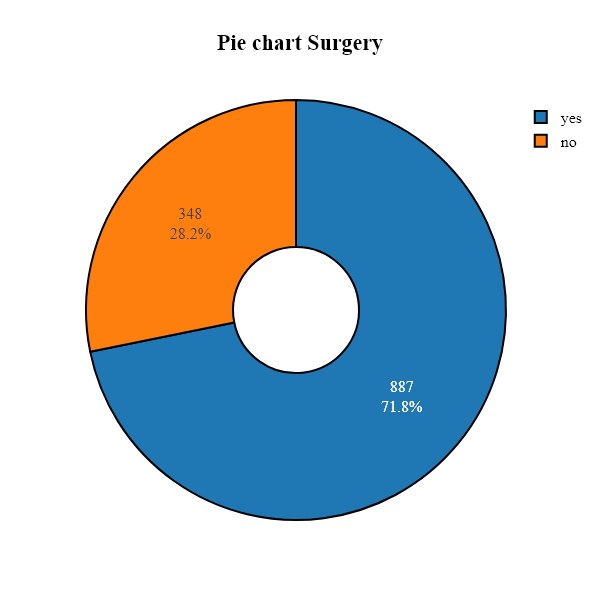

In [506]:
plots = Plots()
plots.pie_chart(data=train_data["surgery"], name="surgery")

$\text{It looks like most of horses had a surgery.}$

$\text{Next feature is age.}$

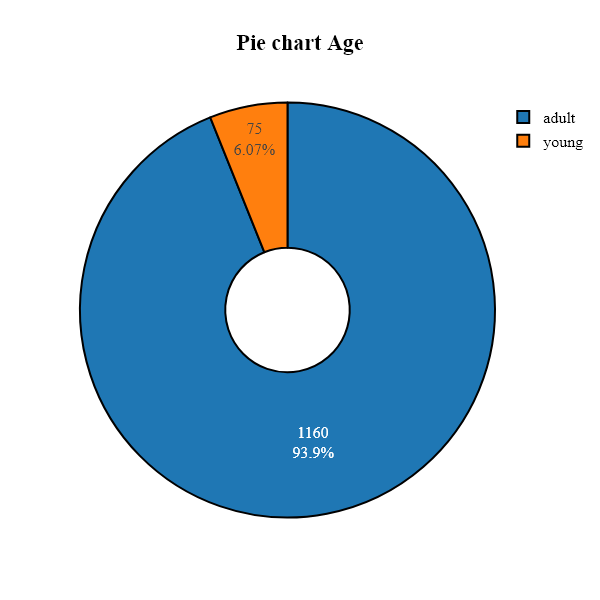

In [507]:
plots.pie_chart(data=train_data["age"], name="age")

$\text{It looks like most of the horses are adults (almost 94\%).}$

$\text{Next feature is hospital\_number.}$

In [508]:
print("Number of unique values: {}".format(len(train_data["hospital_number"].value_counts())))

Number of unique values: 255


$\text{As we can see there are many unique values of this feature.}$<p>
$\text{However it is smaller than number of observations.}$<p>
$\text{In the next stage we will encode it as categorical variable, and create groups for horses.}$

$\text{Next feature is rectal\_temp.}$

In [509]:
plots.hist_plot_with_kde(data=train_data["rectal_temp"], name="rectal_temp", bin_size=0.1)

$\text{As we can see the distribution of this feature is simmilar to normal.}$

$\text{Next feature is pulse.}$

In [510]:
plots.hist_plot_with_kde(data=train_data["pulse"], name="pulse", bin_size=5)

$\text{This feature is a bit right-skewed.}$

$\text{Next feature is respiratory\_rate.}$

In [511]:
plots.hist_plot_with_kde(data=train_data["respiratory_rate"], name="respiratory_rate", bin_size=3)

$\text{Same as for pulse it looks like a right-skewed data.}$

$\text{Next feature is temp\_of\_extremities.}$

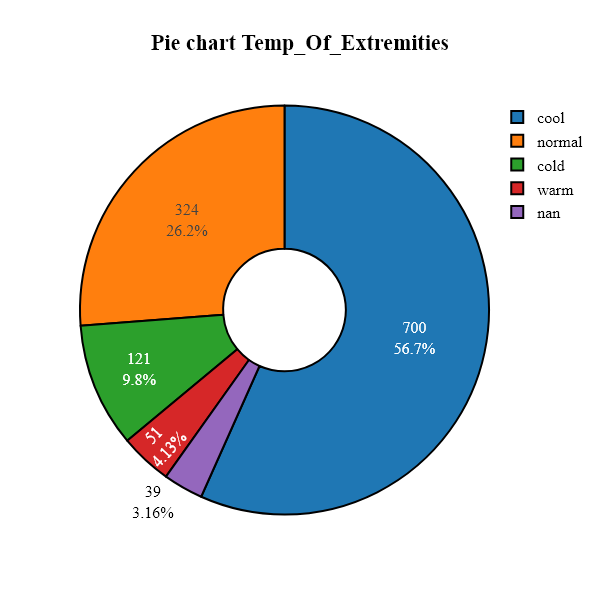

In [512]:
plots.pie_chart(data=train_data["temp_of_extremities"], name="temp_of_extremities")

$\text{For this feature more than 50\% of data is a "cool" category.}$

$\text{Next feature is preipheral\_pulse.}$

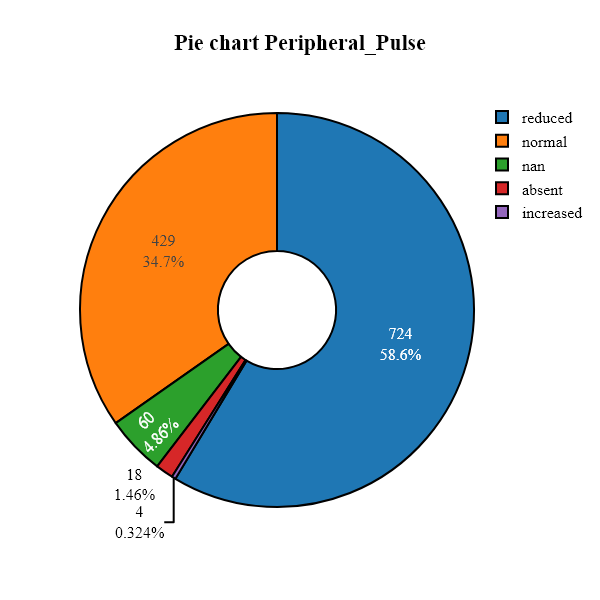

In [513]:
plots.pie_chart(data=train_data["peripheral_pulse"], name="peripheral_pulse")

$\text{Almost 59\% of values for this feature is "reduced" category, second most frequent category is "normal".}$

$\text{Next feature is mucous\_membrane.}$

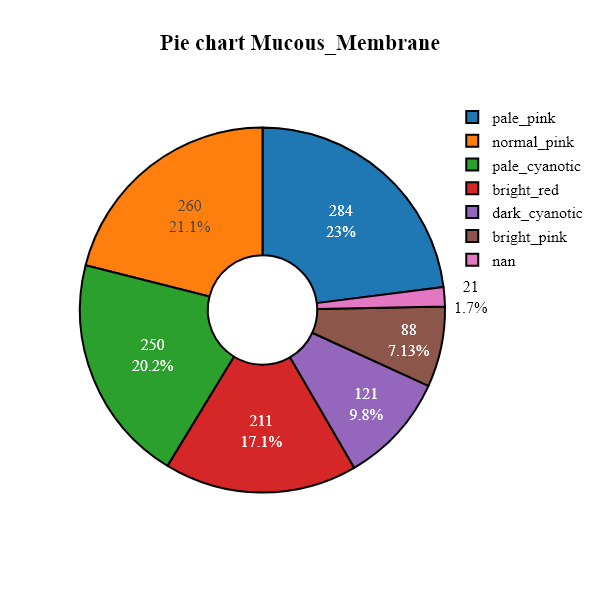

In [514]:
plots.pie_chart(data=train_data["mucous_membrane"], name="mucous_membrane")

$\text{For this feature, categories are almost equally distributed.}$

$\text{Next feature is capillary\_refill\_time.}$

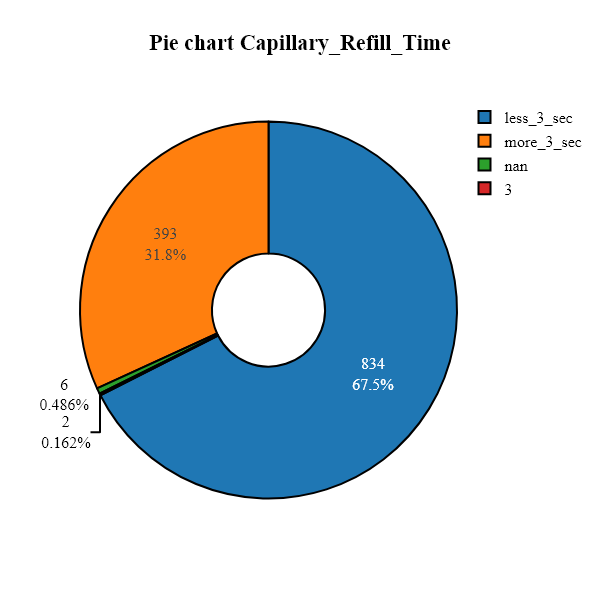

In [515]:
plots.pie_chart(data=train_data["capillary_refill_time"], name="capillary_refill_time")

$\text{For this feature "3" category is least frequent.}$

$\text{Next feature is pain.}$

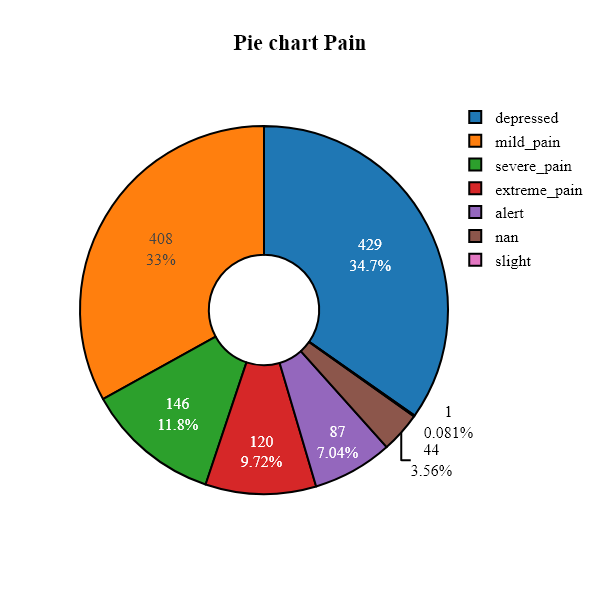

In [516]:
plots.pie_chart(data=train_data["pain"], name="pain")

$\text{Most frequent categories are depressed and mild\_pain.}$

$\text{Next feature is peristalsis.}$

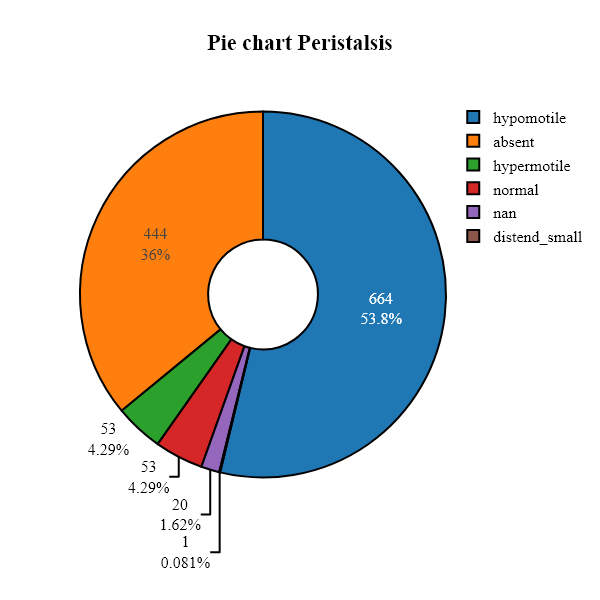

In [517]:
plots.pie_chart(data=train_data["peristalsis"], name="peristalsis")

$\text{Most frequent categories are hypomotil and absent.}$

$\text{Next feature is abdominal\_distention.}$

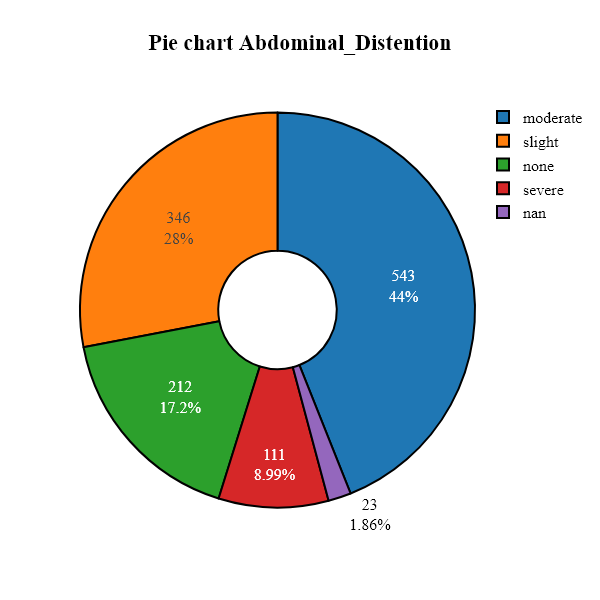

In [518]:
plots.pie_chart(data=train_data["abdominal_distention"], name="abdominal_distention")

$\text{Moderate is a most frequent category.}$

$\text{Next feature is nasogastric\_tube.}$

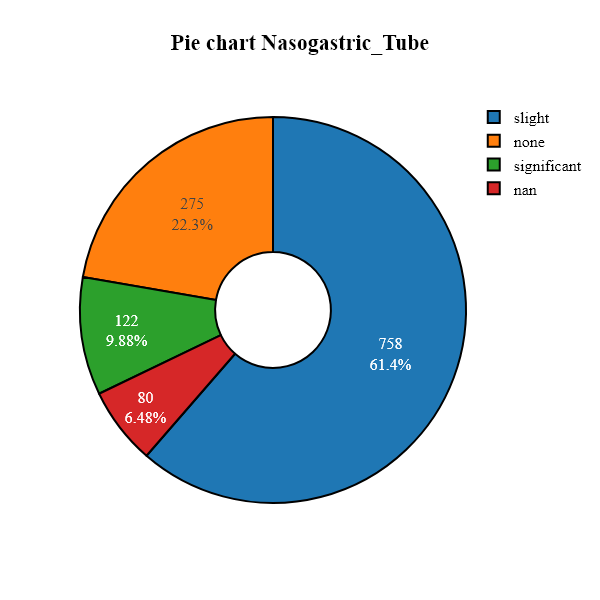

In [519]:
plots.pie_chart(data=train_data["nasogastric_tube"], name="nasogastric_tube")

$\text{Slight is a most frequent category.}$

$\text{Next feature is nasogastric\_reflux.}$

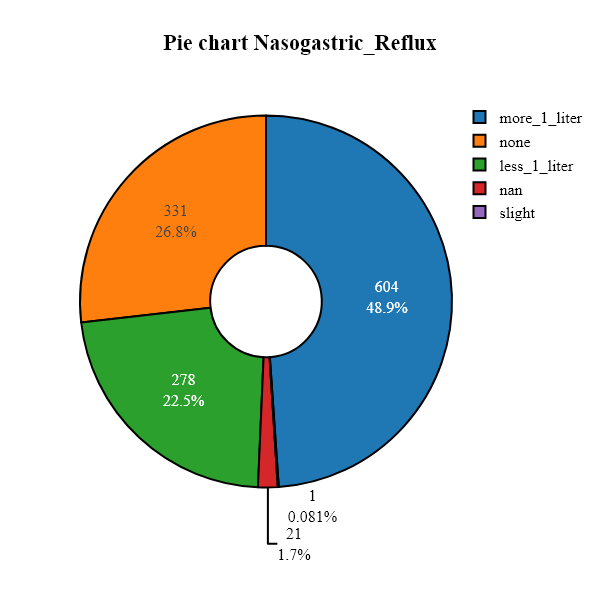

In [520]:
plots.pie_chart(data=train_data["nasogastric_reflux"], name="nasogastric_reflux")

$\text{There is only 1 observation for "slight" category.}$

$\text{Next feature is nasogastric\_reflux\_ph.}$

In [521]:
plots.hist_plot_with_kde(data=train_data["nasogastric_reflux_ph"], name="nasogastric_reflux_ph", bin_size=0.5)

$\text{Next feature is rectal\_exam\_feces.}$

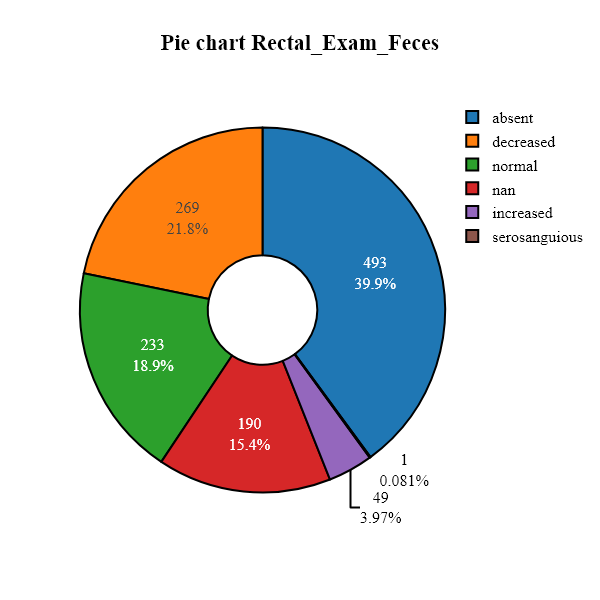

In [522]:
plots.pie_chart(data=train_data["rectal_exam_feces"], name="rectal_exam_feces")

$\text{THere is only 1 observation with "serosanguious" category.}$

$\text{Next feature is abdomen.}$

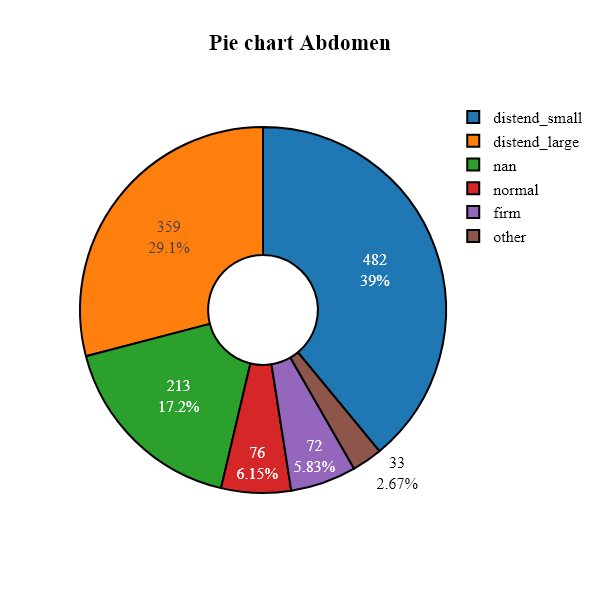

In [523]:
plots.pie_chart(data=train_data["abdomen"], name="abdomen")

$\text{There is a lot of missing values. distned\_small is most frequent category.}$

$\text{Next feature is packed\_cell\_volume.}$

In [524]:
plots.hist_plot_with_kde(data=train_data["packed_cell_volume"], name="packed_cell_volume", bin_size=2)

$\text{Distribution of the data is simmilar to normal distribution.}$

$\text{Next feature is total\_protein.}$

In [525]:
plots.hist_plot_with_kde(data=train_data["total_protein"], name="total_protein", bin_size=1)

$\text{Data is highly right-skewed, we might think of scaling od the data.}$

$\text{Next feature is abdomo\_appearance.}$

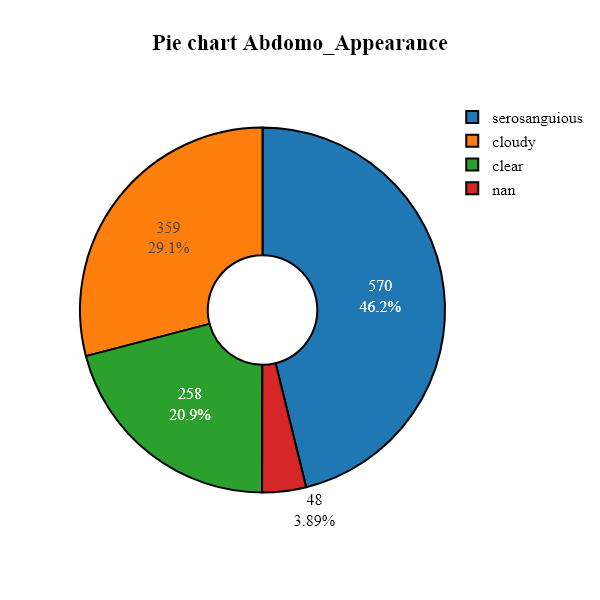

In [526]:
plots.pie_chart(data=train_data["abdomo_appearance"], name="abdomo_appearance")

$\text{Least frequent category is clear.}$

$\text{Next feature is abdomo\_protein.}$

In [527]:
plots.hist_plot_with_kde(data=train_data["abdomo_protein"], name="abdomo_protein", bin_size=0.5)

$\text{Max value for this feature is 10.}$

$\text{Next feature is surgical\_lesion.}$

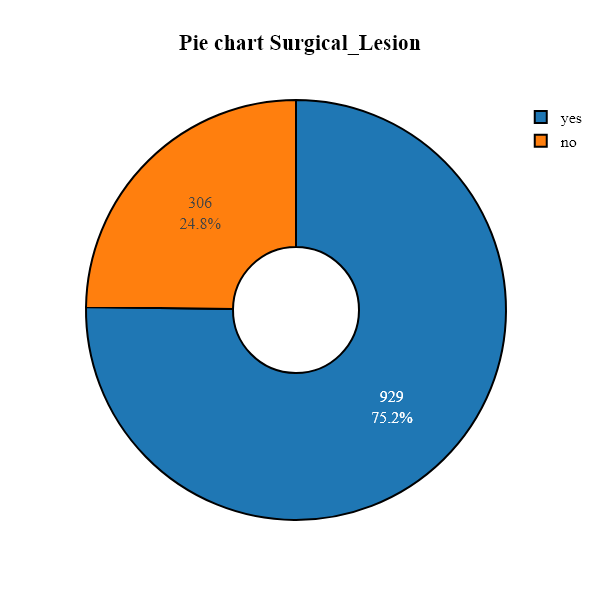

In [528]:
plots.pie_chart(data=train_data["surgical_lesion"], name="surgical_lesion")

$\text{There are no missing values for this feature. Category "yes" is most frequent.}$

$\text{Next feature is lesion\_1.}$

In [529]:
plots.hist_plot_with_kde(data=train_data["lesion_1"], name="lesion_1", bin_size=1000)

$\text{There are outliers for this feature. It looks like Winsorization might be a good technique to impute them.}$

$\text{Next feature is lesion\_2.}$

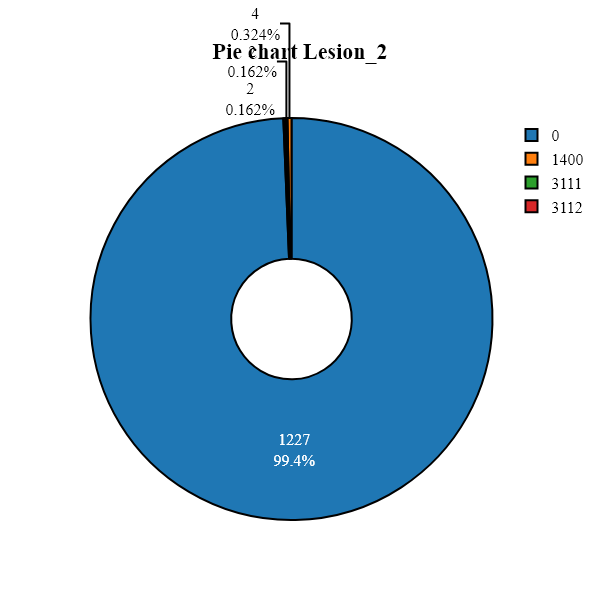

In [530]:
plots.pie_chart(data=train_data["lesion_2"], name="lesion_2")

$\text{For this feature there is almost 100\% of one category - 0.}$<p>
$\text{We will encode other categories as 1}$

In [531]:
train_data["lesion_2"] = train_data["lesion_2"].apply(lambda x: x if x==0 else 1)

$\text{Next feature is lesion\_3.}$

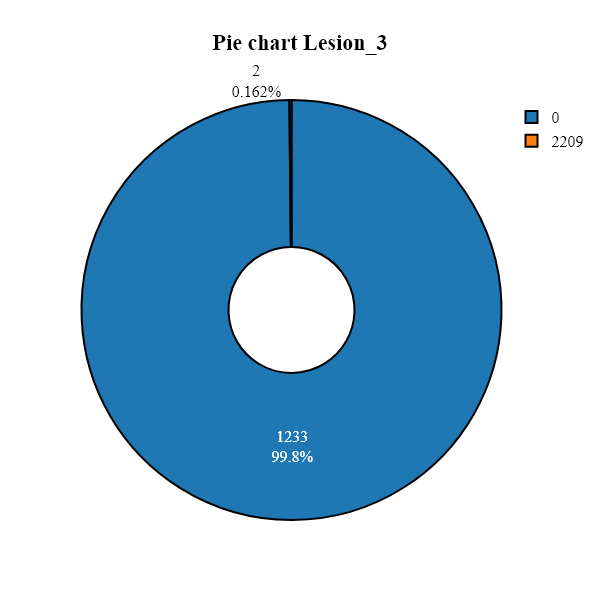

In [532]:
plots.pie_chart(data=train_data["lesion_3"], name="lesion_3")

$\text{For this feature data is highly imbalanced.}$

$\text{Next feature is cp\_data.}$

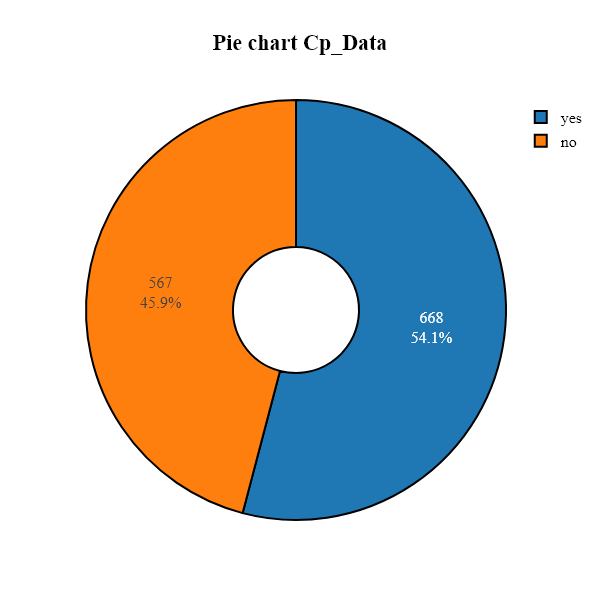

In [533]:
plots.pie_chart(data=train_data["cp_data"], name="cp_data")

$\text{Data is balanced for this feature.}$

$\text{Our dependent variable: outcome}$

In [534]:
plots.barplot(data=train_data["outcome"], name="outcome")

$\text{Most frequent category is lived, and least frequent is euthanized.}$

<a id="8"></a>
## Distribution of dependent variable for each feature

$\text{Define continous variables.}$

In [535]:
list_of_continous_features = ['rectal_temp', 'pulse', 'respiratory_rate', 'nasogastric_reflux_ph', 'packed_cell_volume', 'total_protein', "abdomo_protein", "lesion_1"]

In [536]:
bin_size = [0.1, 5, 3, 0.5, 2, 1, 0.5, 1000]
for idx, feature in enumerate(list_of_continous_features):
    plots.hist_plot_with_kde_and_hue(data=train_data.loc[train_data[feature].isna()==False][feature], hue=train_data.loc[train_data[feature].isna()==False]["outcome"], name=f"{feature} by outcome", bin_size=bin_size[idx])

$\text{Notes:}$<p>
$\text{- For Pulse < 60 -> horses are more likely to be lived.}$<p>
$\text{- For Nasogastric\_reflux\_ph < 2.5 -> horses are more likely to be euthanized.}$<p>
$\text{- For Packed\_cell\_volume >= 50 -> horses are more likely to be euthanized.}$<p>
$\text{- For Total\_protein >= 45 -> horses are more likely to be euthanized.}$<p>
$\text{We can create new categorical variables for each of these observations.}$

In [537]:
train_data["pulse_group"] = train_data["pulse"].apply(lambda x: "lived" if x < 60 else (np.nan if pd.isnull(x) else "Other"))
train_data["nasogastric_reflux_ph_group"] = train_data["nasogastric_reflux_ph"].apply(lambda x: "euthanized" if x < 2.5 else (np.nan if pd.isnull(x) else "Other"))
train_data["packed_cell_volume_group"] = train_data["packed_cell_volume"].apply(lambda x: "euthanized" if x >= 50 else (np.nan if pd.isnull(x) else "Other"))
train_data["total_protein_group"] = train_data["total_protein"].apply(lambda x: "euthanized" if x >= 50 else (np.nan if pd.isnull(x) else "Other"))

$\text{Define list of categorical variables.}$

In [538]:
list_of_categorical_features = ['surgery', 'age', 'hospital_number', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', "peristalsis", "abdominal_distention", "nasogastric_tube", "nasogastric_reflux", "rectal_exam_feces", "abdomen", "abdomo_appearance", "surgical_lesion", "lesion_2", "lesion_3", "cp_data", "pulse_group", "nasogastric_reflux_ph_group", "packed_cell_volume_group", "total_protein_group"]

In [539]:
for feature in list_of_categorical_features:
    plots.barplot_with_hue(data=train_data[feature], hue=train_data["outcome"], name=f"{feature} by outcome")

$\text{Notes:}$<p>
$\text{- age: For 'adult' category euthanized is most frequent label and for 'young' died is most frequent.}$<p>
$\text{- capillary\_refill\_time: simmilarly to age variable it looks like the feature seperate well target variable.}$<p>
$\text{- abdomo\_appearance: for serosanguious category most frequent label is 'died'.}$

<a id="9"></a>
# Data Cleaning

$\text{Firstly, let's create a countplot of missing values.}$

In [540]:
count_of_missing=train_data.isna().sum(axis=1)
plots.barplot_with_hue(data=count_of_missing, hue=train_data[target_variable], name="Count of missing values")
print("Percentage of observations with at least one missing value: {}%".format(np.round(100*len(count_of_missing[count_of_missing>0])/len(count_of_missing), 4)))
print("Percentage of missing values in whole dataset: {}%".format(np.round(100*count_of_missing.sum()/(len(train_data)*len(train_data.columns.tolist())), 4)))

Percentage of observations with at least one missing value: 37.5709%
Percentage of missing values in whole dataset: 1.9357%


$\text{Notes:}$<P>
$\text{- Missing values are independent of the target (in terms of target distribution) and for the most part are isolated.}$<p>
$\text{- Even though only 2\% of the data is missing, about 37.5\% of all observations have at least 1 missing value.}$

$\text{Plot missing values per column.}$

In [541]:
missing_data = pd.DataFrame(train_data.isna().sum()/train_data.shape[0],columns=['Missing Percentage']).sort_values(by='Missing Percentage',ascending=False)
missing_data = missing_data.loc[missing_data['Missing Percentage']>0, :]
missing_columns = list(missing_data.index)

In [542]:
plots.barplot_missing_values(data=missing_data, features_names=missing_columns, name="missing values")

In [543]:
train_data.loc[:,missing_columns]

,abdomen,rectal_exam_feces,nasogastric_tube,peripheral_pulse,abdomo_appearance,pain,temp_of_extremities,abdominal_distention,mucous_membrane,nasogastric_reflux,peristalsis,capillary_refill_time
0,distend_small,decreased,slight,reduced,serosanguious,depressed,cool,slight,dark_cyanotic,less_1_liter,absent,more_3_sec
1,distend_small,absent,none,normal,serosanguious,mild_pain,cool,moderate,pale_cyanotic,more_1_liter,absent,more_3_sec
2,distend_large,NaN,slight,reduced,serosanguious,extreme_pain,cool,moderate,pale_pink,none,hypomotile,less_3_sec
3,distend_small,decreased,slight,reduced,cloudy,mild_pain,cold,moderate,pale_pink,more_1_liter,hypomotile,more_3_sec
4,normal,normal,slight,normal,cloudy,alert,normal,none,normal_pink,less_1_liter,hypomotile,less_3_sec
...,...,...,...,...,...,...,...,...,...,...,...,...
1230,distend_large,NaN,none,reduced,serosanguious,depressed,cool,moderate,pale_pink,more_1_liter,absent,more_3_sec
1231,distend_small,decreased,slight,reduced,serosanguious,mild_pain,cool,slight,pale_cyanotic,none,hypomotile,less_3_sec
1232,firm,increased,slight,reduced,cloudy,mild_pain,normal,slight,normal_pink,none,hypomotile,less_3_sec
1233,distend_small,absent,none,reduced,cloudy,mild_pain,normal,slight,bright_red,more_1_liter,hypomotile,less_3_sec


$\text{Looks like all missing values are categorical.}$<p>
$\text{One of the method to impute missing values is CatBoost, so we will use it in the next section.}$

$\text{We can also take a look into insights of our data.}$<p>
$\text{The way to do this is by looking at the joint distribution of features.}$

In [544]:
plots.scatter_matrix(data=train_data[list_of_continous_features], hue=train_data[target_variable])

$\text{Notes:}$<p>
$\text{- There is no clear linear relationship between continous variables (except of Total\_Expanditure feature).}$

$\text{There are also many combinations to summerise useful trends between continous and categorical variables.}$<p>
$\text{After creating some heatmaps dependent of target variable there was no clear signs of possible imputation.}$

$\text{Therefore we will use advanced techniques to impute missing values.}$

$\text{Divide our data into X and y variables.}$

In [545]:
X = train_data.drop("outcome", axis=1)
y = train_data["outcome"]

$\text{Before moving onto the next section we will encode categorical features.}$<p>
$\text{At the current stage for categorical features we will use OrdinalEncoder to transform them into numerical type.}$<p>
$\text{In the next section we will use get\_dummies to create more features.}$

In [546]:
encoder = OrdinalEncoder()
X[list_of_categorical_features] = encoder.fit_transform(X[list_of_categorical_features])
y = pd.Series(encoder.fit_transform(y.values.reshape(-1, 1)).squeeze(), name="outcome")

$\text{There are many techniques that we can use to deal with missing values.}$<p>
$\text{These range from simple mean/median imputation, or inserting an arbitrary value to using machine learning algorithms for imputation.}$<p>
$\text{One of the most popular in recent times is KNNImputer.}$<p>
$\text{We will try several techniques and with Cross validation and roc auc score compare them.}$<p>
$\text{As a base model we will use LightGBM which works pretty well and fast with base parameters.}$

<a id="10"></a>
## Drop missing values

In [547]:
indices_of_missing_values = X[X.isnull().any(axis=1)].index.tolist()
X_copy = X[~X.index.isin(indices_of_missing_values)]
y_copy = y[~y.index.isin(indices_of_missing_values)]
X_copy.reset_index(drop=True, inplace=True)
y_copy.reset_index(drop=True, inplace=True)
print("Ratio of new data (compared to original one) after removing missing values: {}%".format(np.round(100*len(X_copy)/len(X), 4)))

Ratio of new data (compared to original one) after removing missing values: 62.4291%


$\text{As we can see, we have removed almost 40\% of data.}$<p>
$\text{That's a lot... we have to think whether our information loss due to that drop will not affect scores.}$

In [548]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y_copy)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y_copy.iloc[train_idx], y_copy.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.6796


<a id="11"></a>
## Drop rows with many missing values

$\text{As we could have seen for the first method - information loss after dropping rows with at least one missing value was to big...}$<p>
$\text{Therefore we will drop only these rows for which there were many missing values.}$<p>
$\text{Rest of them we will impute with Iterative Imputer.}$

In [549]:
class Iterative_Missing_values_Imputer():
    def __init__(self, estimator_regression, estimator_classification, initial_strategy="mean", imputation_order="ascending", random_state=17):
        self.estimator_regression = estimator_regression
        self.estimator_classification = estimator_classification
        statistics = {
            'mean': self.calculate_mean,
            'median': self.calculate_median,
            'mode': self.calculate_mode,
            "constant": self.calculate_constant
        }
        self.initial_strategy = initial_strategy
        self.calculate_statistic = statistics[self.initial_strategy]
        imputation_orders = {
            'ascending': self.ascending_order,
            'descending': self.descending_order,
            'random': self.random_order
        }
        self.imputation_order = imputation_orders[imputation_order]
        self.random_state = random_state
        np.random.seed(self.random_state)
        random.seed(self.random_state)
        self.fit_used = False
    
    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        return np.array(X)
    
    def fit(self, X, categorical_features=[]):
        self.categorical_features = self.find_numeric_order_of_columns(X=self.X_train, categorical_features=categorical_features)
        self.X_train = self.check_X(X=X)
        self.statistic_for_each_column = self.find_statistics(X=self.X_train, categorical_features=self.categorical_features)
        self.fit_used = True
    
    def fit_transform(self, X, categorical_features=[]):
        self.categorical_features = self.find_numeric_order_of_columns(X=X, categorical_features=categorical_features)
        self.X_train = self.check_X(X=X)
        self.statistic_for_each_column = self.find_statistics(X=self.X_train, categorical_features=self.categorical_features)
        missing_values_mask = np.isnan(self.X_train)
        order_of_columns = self.imputation_order(missing_values_mask=missing_values_mask)
        self.X_train = self.iterative_imputation_train(X=self.X_train, missing_values_mask=missing_values_mask, order_of_columns=order_of_columns)
        self.fit_used = True
        return self.X_train
    
    def transform(self, X_test):
        self.check_fit(fit_used=self.fit_used)
        X_test = self.check_X(X=X_test)
        missing_values_mask = np.isnan(X_test)
        order_of_columns = self.imputation_order(missing_values_mask=missing_values_mask)
        X_imputed = self.iterative_imputation_test(X_train=self.X_train, X_test=X_test, missing_values_mask=missing_values_mask, order_of_columns=order_of_columns)
        return X_imputed
    
    def find_numeric_order_of_columns(self, X, categorical_features):
        if(all(isinstance(element, str) for element in categorical_features) == True and isinstance(X, pd.DataFrame)):
            categorical_features = [index for index, feature in enumerate(X.columns) if feature in categorical_features]
        return categorical_features
    
    def find_statistics(self, X, categorical_features):
        statistic_for_each_column = []
        for feature in range(0, X.shape[1]):
            if(self.initial_strategy == "constant"):
                if(feature in categorical_features):
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature], categorical=True))
                else:
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature], categorical=False))
            else:
                if(feature in categorical_features):
                    statistic_for_each_column.append(self.calculate_mode(X=X[:, feature]))
                else:
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature]))
        return statistic_for_each_column
    
    def ascending_order(self, missing_values_mask):
        sorted_features_with_missing_values = np.argsort(missing_values_mask.sum(axis=0))
        features_with_missing_values = np.argwhere(np.sum(missing_values_mask, axis=0)).squeeze()
        intersection, sorted_idx, features_idx = np.intersect1d(sorted_features_with_missing_values, features_with_missing_values, return_indices=True)
        return sorted_features_with_missing_values[np.sort(sorted_idx)]
        
    def descending_order(self, missing_values_mask):
        sorted_features_with_missing_values = np.argsort(missing_values_mask.sum(axis=0))[::-1]
        features_with_missing_values = np.argwhere(np.sum(missing_values_mask, axis=0)).squeeze()
        intersection, sorted_idx, features_idx = np.intersect1d(sorted_features_with_missing_values, features_with_missing_values, return_indices=True)
        return sorted_features_with_missing_values[np.sort(sorted_idx)]
    
    def random_order(self, missing_values_mask):
        features_with_missing_values = np.argwhere(np.sum(missing_values_mask, axis=0)).squeeze()
        random.shuffle(features_with_missing_values)
        return features_with_missing_values
    
    def calculate_mean(self, X):
        return np.nanmean(X, axis=0)
    
    def calculate_median(self, X):
        return np.nanmedian(X, axis=0)
    
    def calculate_mode(self, X):
        return mode(X, nan_policy="omit", keepdims=True)[0][0]
    
    def calculate_constant(self, X, categorical=False):
        if(categorical == True):
            return -99
        else:
            return 0


    def statistic_imputation(self, X, missing_values_mask):
        for feature in range(0, X.shape[1]):
            X[missing_values_mask[:, feature], feature] = self.statistic_for_each_column[feature]
        return X

    def iterative_imputation_train(self, X, missing_values_mask, order_of_columns):
        X_imputed = self.statistic_imputation(X=X, missing_values_mask=missing_values_mask)
        for feature in order_of_columns:
            X_inner = np.delete(X_imputed, feature, axis=1)
            y_inner = X_imputed[:, feature]
            X_inner_train = np.delete(X_inner, missing_values_mask[:, feature], axis=0)
            y_inner_train = np.delete(y_inner, missing_values_mask[:, feature], axis=0)
            X_inner_test = X_inner[missing_values_mask[:, feature], :]
            if(feature in self.categorical_features):
                self.estimator_classification.fit(X_inner_train, y_inner_train)
                X_imputed[missing_values_mask[:, feature], feature] = self.estimator_classification.predict(X_inner_test)
            else:
                self.estimator_regression.fit(X_inner_train, y_inner_train)
                X_imputed[missing_values_mask[:, feature], feature] = self.estimator_regression.predict(X_inner_test)
        return X_imputed

    def iterative_imputation_test(self, X_train, X_test, missing_values_mask, order_of_columns):
        X_test_imputed = self.statistic_imputation(X=X_test, missing_values_mask=missing_values_mask)
        for feature in order_of_columns:
            X_inner_train = np.delete(X_train, feature, axis=1)
            y_inner_train = X_train[:, feature]
            X_inner_test = X_test_imputed[missing_values_mask[:, feature], :]
            X_inner_test = np.delete(X_inner_test, feature, axis=1)
            if(feature in self.categorical_features):
                self.estimator_classification.fit(X_inner_train, y_inner_train)
                X_test_imputed[missing_values_mask[:, feature], feature] = self.estimator_classification.predict(X_inner_test)
            else:
                self.estimator_regression.fit(X_inner_train, y_inner_train)
                X_test_imputed[missing_values_mask[:, feature], feature] = self.estimator_regression.predict(X_inner_test)
        return X_test_imputed

    def check_fit(self, fit_used):
        if fit_used == False:
            raise AttributeError('Iterative_Missing_values_Imputer has to be fitted first.')

In [550]:
condition = X[X.isnull().any(axis=1)].count(axis=1) <= 28
indices_to_drop = condition[condition].index.tolist()
X_copy = X[~X.index.isin(indices_to_drop)]
y_copy = y[~y.index.isin(indices_to_drop)]

In [551]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
iterative_imputer = Iterative_Missing_values_Imputer(estimator_regression=BayesianRidge(), estimator_classification=BayesianRidge(), initial_strategy="constant", imputation_order="ascending", random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y_copy)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y_copy.iloc[train_idx], y_copy.iloc[valid_idx]
    X_train_iterative_imputer = iterative_imputer.fit_transform(X_train)
    X_valid_iterative_imputer = iterative_imputer.transform(X_valid)
    algorithm.fit(X_train_iterative_imputer, y_train)
    y_train_pred = algorithm.predict(X_train_iterative_imputer)
    y_valid_pred = algorithm.predict(X_valid_iterative_imputer)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7264


<a id="12"></a>
## Arbitrary Value

In [552]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y[train_idx], y[valid_idx]
    X_train_arbitrary = X_train.fillna(-99)
    X_valid_arbitrary = X_valid.fillna(-99)
    algorithm.fit(X_train_arbitrary, y_train)
    y_train_pred = algorithm.predict(X_train_arbitrary)
    y_valid_pred = algorithm.predict(X_valid_arbitrary)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7077


<a id="13"></a>
## Median (continous) and mode (categorical) imputation

In [553]:
class Simple_Imputer():
    def __init__(self, continous_strategy="mean", random_state=17):
        statistics = {
            'mean': self.calculate_mean,
            'median': self.calculate_median,
            'mode': self.calculate_mode,
            "constant": self.calculate_constant
        }
        self.initial_strategy = continous_strategy
        self.calculate_statistic = statistics[continous_strategy]
        self.random_state = random_state
        np.random.seed(self.random_state)
        random.seed(self.random_state)
        self.fit_used = False

    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        return np.array(X)

    def fit(self, X, categorical_features=[]):
        self.categorical_features = self.find_numeric_order_of_columns(X=X, categorical_features=categorical_features)
        X = self.check_X(X=X)
        self.statistic_for_each_column = self.find_statistics(X=X, categorical_features=self.categorical_features)
        self.fit_used = True
    
    def fit_transform(self, X, categorical_features=[]):
        self.categorical_features = self.find_numeric_order_of_columns(X=X, categorical_features=categorical_features)
        X = self.check_X(X=X)
        self.statistic_for_each_column = self.find_statistics(X=X, categorical_features=self.categorical_features)
        X_imputed = self.impute_missing_values(X=X)
        self.fit_used = True
        return X_imputed
    
    def transform(self, X):
        self.check_fit(fit_used=self.fit_used)
        X = self.check_X(X=X)
        X_imputed = self.impute_missing_values(X=X)
        return X_imputed
    
    def find_numeric_order_of_columns(self, X, categorical_features):
        if(all(isinstance(element, str) for element in categorical_features) == True and isinstance(X, pd.DataFrame)):
            categorical_features = [index for index, feature in enumerate(X.columns) if feature in categorical_features]
        return categorical_features

    def find_statistics(self, X, categorical_features):
        statistic_for_each_column = []
        for feature in range(0, X.shape[1]):
            if(self.initial_strategy == "constant"):
                if(feature in categorical_features):
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature], categorical=True))
                else:
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature], categorical=False))
            else:
                if(feature in categorical_features):
                    statistic_for_each_column.append(self.calculate_mode(X=X[:, feature]))
                else:
                    statistic_for_each_column.append(self.calculate_statistic(X=X[:, feature]))
        return statistic_for_each_column

    def calculate_mean(self, X):
        return np.nanmean(X)
    
    def calculate_median(self, X):
        return np.nanmedian(X)
    
    def calculate_mode(self, X):
        return mode(X, nan_policy="omit", keepdims=True)[0][0]
    
    def calculate_constant(self, X, categorical=False):
        if(categorical == True):
            return -99
        else:
            return 0
    
    def impute_missing_values(self, X):
        for feature in range(0, X.shape[1]):
            X[np.where(np.isnan(X[:, feature])), feature] = self.statistic_for_each_column[feature]
        return X
    
    def check_fit(self, fit_used):
        if fit_used == False:
            raise AttributeError('Simple_Imputer has to be fitted first.')

In [554]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
simple_imputer = Simple_Imputer(continous_strategy="mean", random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y[train_idx], y[valid_idx]
    X_train_simple_imputer = simple_imputer.fit_transform(X=X_train, categorical_features=list_of_categorical_features)
    X_valid_simple_imputer = simple_imputer.transform(X=X_valid)
    algorithm.fit(X_train_simple_imputer, y_train)
    y_train_pred = algorithm.predict(X_train_simple_imputer)
    y_valid_pred = algorithm.predict(X_valid_simple_imputer)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.698


<a id="14"></a>
## CatBoost Imputer

$\text{Because for CatBoost we need string columns for ccategorical features, we will create a new X\_cat for that.}$

In [555]:
X_cat = train_data.drop("outcome", axis=1)
X_cat.fillna('Missing_value', inplace=True)

In [556]:
condition = X_cat[X_cat.isnull().any(axis=1)].count(axis=1) <= 28
indices_to_drop = condition[condition].index.tolist()
X_copy = X_cat[~X_cat.index.isin(indices_to_drop)]
y_copy = y[~y.index.isin(indices_to_drop)]

In [557]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y_copy[train_idx], y_copy[valid_idx]
    #RESET INDEX
    for feature in missing_columns:
        #Train data
        df_train_missing = X_train.loc[X_train[feature]=='Missing_value']
        X_train_missing = df_train_missing.drop(feature, axis=1)
        y_train_missing = df_train_missing.loc[:, feature]
        df_train_not_missing = X_train.loc[~(X_train[feature]=='Missing_value')]
        X_train_not_missing = df_train_not_missing.drop(feature, axis=1)
        y_train_not_missing = df_train_not_missing.loc[:, feature]
        categorical_feature_indices = [i for i, col in enumerate(X_train_missing.columns) if X_train_missing[col].dtype=='object']
        label_encoder = LabelEncoder()
        y_train_not_missing = label_encoder.fit_transform(y_train_not_missing)
        #Modelling
        model = CatBoostClassifier(iterations=50, learning_rate=0.2, max_depth=4, cat_features=categorical_feature_indices, verbose=0)
        model.fit(X_train_not_missing, y_train_not_missing)

        #Imputing missing values train
        y_train_predict = model.predict(X_train_missing)
        y_train_predict = label_encoder.inverse_transform(y_train_predict)
        X_train.loc[X_train[feature]=='Missing_value', feature] = y_train_predict

        #Validation data
        df_valid_missing = X_valid.loc[X_valid[feature]=='Missing_value']
        X_valid_missing = df_valid_missing.drop(feature, axis=1)
        y_valid_missing = df_valid_missing.loc[:, feature]
        df_valid_not_missing = X_valid.loc[~(X_valid[feature]=='Missing_value')]
        X_valid_not_missing = df_valid_not_missing.drop(feature, axis=1)
        y_valid_not_missing = df_valid_not_missing.loc[:, feature]

        #Imputing missing values valid
        y_valid_predict = model.predict(X_valid_missing)
        y_valid_predict = label_encoder.inverse_transform(y_valid_predict)
        X_valid.loc[X_valid[feature]=='Missing_value', feature] = y_valid_predict
    #We have to convert this object columns to numeric
    encoder = OrdinalEncoder()
    #categorical_without_hospital = [feature for feature in list_of_categorical_features if feature != "hospital_number"]
    X_train[list_of_categorical_features] = encoder.fit_transform(X_train[list_of_categorical_features])
    X_valid[list_of_categorical_features] = encoder.fit_transform(X_valid[list_of_categorical_features])
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))    

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.681


In [558]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
iterative_imputer = Iterative_Missing_values_Imputer(estimator_regression=BayesianRidge(), estimator_classification=BayesianRidge(), initial_strategy="constant", imputation_order="ascending", random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    X_train_iterative_imputer = iterative_imputer.fit_transform(X_train)
    X_valid_iterative_imputer = iterative_imputer.transform(X_valid)
    algorithm.fit(X_train_iterative_imputer, y_train)
    y_train_pred = algorithm.predict(X_train_iterative_imputer)
    y_valid_pred = algorithm.predict(X_valid_iterative_imputer)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7004


<a id="15"></a>
## KNN Imputation

$\text{For KNN algorithm we should scale our data, therefore we will use StandardScaler.}$

In [559]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
knn_imputer = KNNImputer(n_neighbors=10, weights="uniform", metric="nan_euclidean")
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y[train_idx], y[valid_idx]
    scaler = StandardScaler()
    X_train[list_of_continous_features] = scaler.fit_transform(X_train[list_of_continous_features])
    X_valid[list_of_continous_features] = scaler.transform(X_valid[list_of_continous_features])
    X_train_knn_imputer = knn_imputer.fit_transform(X_train)
    X_train_knn_imputer = pd.DataFrame(X_train_knn_imputer, columns=X_train.columns.tolist())
    X_valid_knn_imputer = knn_imputer.transform(X_valid)
    X_valid_knn_imputer = pd.DataFrame(X_valid_knn_imputer, columns=X_valid.columns.tolist())
    X_train_knn_imputer[list_of_continous_features] = scaler.inverse_transform(X_train_knn_imputer[list_of_continous_features])
    X_valid_knn_imputer[list_of_continous_features] = scaler.inverse_transform(X_valid_knn_imputer[list_of_continous_features])
    algorithm.fit(X_train_knn_imputer, y_train)
    y_train_pred = algorithm.predict(X_train_knn_imputer)
    y_valid_pred = algorithm.predict(X_valid_knn_imputer)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.6972


$\text{Well it looks like with droping many missing values and then using IterativeImputer is a good idea.}$<p>
$\text{Therefore we will use these imputed values in the next section.}$

In [560]:
all_columns = X.columns.tolist()
condition = X[X.isnull().any(axis=1)].count(axis=1) <= 28
indices_to_drop = condition[condition].index.tolist()
X = X[~X.index.isin(indices_to_drop)]
y = y[~y.index.isin(indices_to_drop)]
X.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)
iterative_imputer = Iterative_Missing_values_Imputer(estimator_regression=BayesianRidge(), estimator_classification=BayesianRidge(), initial_strategy="median", imputation_order="ascending", random_state=17)
X = iterative_imputer.fit_transform(X)
X = pd.DataFrame(X, columns=all_columns)

<a id="16"></a>
# Outliers imputation

$\text{Similarly to Missing values imputation, there are a lot of techniques we can use.}$<p>
$\text{We will compare some of them with Cross Validation.}$<p>
$\text{Before using all of the continous features, we will check skewness of each of them.}$<p>
$\text{We are doing that because some histograms looked like a quite good normal distribution.}$<p>
$\text{For these features there might be no need to impute outliers.}$

In [561]:
class Skewness:
    def __init__(self):
        pass

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        data = np.array(data)
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_for_object_columns(self, data):
        data = pd.DataFrame(data)
        if data.select_dtypes(include=np.number).shape[1] != data.shape[1]:
            raise TypeError('Your data contains object or string columns. Numeric data is obligated.')
        return np.array(data)

    def calculate_skewness(self, data):
        data = self.check_data(data=data)
        data = self.check_for_object_columns(data=data)
        return np.sum((data-np.mean(data))**3)/((data.shape[0]-1)*np.std(data)**3)

    def logarithmic_transformation(self, data):
        data = self.check_data(data=data)
        data = self.check_for_object_columns(data=data)
        return np.log(data)
    
    def square_root_transformation(self, data):
        data = self.check_data(data=data)
        data = self.check_for_object_columns(data=data)
        return np.sqrt(data)
    
    def box_cox_transformation(self, data, reg_lambda=0):
        data = self.check_data(data=data)
        data = self.check_for_object_columns(data=data)
        if(reg_lambda==0):
            return self.logarithmic_transformation(data=data)
        else:
            return (data**reg_lambda-1)/reg_lambda

In [562]:
skew = Skewness()
for feature in list_of_continous_features:
    print("Skewness of {} variable is: {}".format(feature, skew.calculate_skewness(data=X[feature])))

Skewness of rectal_temp variable is: 0.19242045266110164
Skewness of pulse variable is: 0.7261473190987432
Skewness of respiratory_rate variable is: 1.5706040514704287
Skewness of nasogastric_reflux_ph variable is: -0.10278786165495303
Skewness of packed_cell_volume variable is: 0.5203931718923609
Skewness of total_protein variable is: 1.5313326291376854
Skewness of abdomo_protein variable is: 1.0208722546209212
Skewness of lesion_1 variable is: 4.228258693725623


$\text{As we can see some of the features have higher skewness of distribution than others.}$<p>
$\text{We will try to remove outliers/scale data for only some of them: respiratory\_rate, total\_protein, abdomo\_protein, lesion\_1}$

In [563]:
list_of_continous_features_to_transform = ['respiratory_rate', 'total_protein', "abdomo_protein", "lesion_1"]

$\text{For each method we will impute iteratively these features to detect whether any scaling of feature will improve base results.}$

In [564]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7086


In [565]:
base_valid_score = 0.7086

<a id="17"></a>
## Quantile Transformer

In [566]:
from sklearn.preprocessing import *
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
scaler = QuantileTransformer(n_quantiles=100, output_distribution="uniform")
train_scores, valid_scores = [], []
for feature in list_of_continous_features_to_transform:
    for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        X_train.reset_index(drop=True, inplace=True)
        X_valid.reset_index(drop=True, inplace=True)
        continous_data_train = X_train[feature]
        continous_data_valid = X_valid[feature]
        X_train_continous_scaled = scaler.fit_transform(np.array(continous_data_train).reshape(-1, 1))
        X_valid_continous_scaled = scaler.transform(np.array(continous_data_valid).reshape(-1, 1))
        X_train_scaled = pd.DataFrame(X_train_continous_scaled, columns=[feature])
        X_valid_scaled = pd.DataFrame(X_valid_continous_scaled, columns=[feature])
        X_train_scaled = pd.concat([X_train_scaled, X_train.drop(feature, axis=1)], axis=1)
        X_valid_scaled = pd.concat([X_valid_scaled, X_valid.drop(feature, axis=1)], axis=1)
        algorithm.fit(X_train_scaled, y_train)
        y_train_pred = algorithm.predict(X_train_scaled)
        y_valid_pred = algorithm.predict(X_valid_scaled)
        train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
        valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
    if(np.mean(valid_scores) > base_valid_score):
        print("After transforming feature: {}, we obtained better valid results, because: {} > {}".format(feature, np.round(np.mean(valid_scores), 4), base_valid_score))

After transforming feature: total_protein, we obtained better valid results, because: 0.7107 > 0.7086
After transforming feature: abdomo_protein, we obtained better valid results, because: 0.71 > 0.7086
After transforming feature: lesion_1, we obtained better valid results, because: 0.7105 > 0.7086


$\text{As we can see for 3 features we have obtained better results.}$<p>
$\text{We will check whether overall scores will improve after scaling them.}$

$\text{As we can see for all features we have obtained better results.}$<p>
$\text{However for only two of the features: respiratory\_rate and total\_protein scores were noticeably better.}$<p>
$\text{We will check whether overall scores will improve after scaling them.}$

In [567]:
features_quantile_transformer = ['total_protein', 'abdomo_protein', 'lesion_1']
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
scaler = QuantileTransformer(n_quantiles=100, output_distribution="uniform")
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    X_train.reset_index(drop=True, inplace=True)
    X_valid.reset_index(drop=True, inplace=True)
    continous_data_train = X_train[features_quantile_transformer]
    continous_data_valid = X_valid[features_quantile_transformer]
    X_train_continous_scaled = scaler.fit_transform(continous_data_train)
    X_valid_continous_scaled = scaler.transform(continous_data_valid)
    X_train_scaled = pd.DataFrame(X_train_continous_scaled, columns=features_quantile_transformer)
    X_valid_scaled = pd.DataFrame(X_valid_continous_scaled, columns=features_quantile_transformer)
    X_train_scaled = pd.concat([X_train_scaled, X_train.drop(features_quantile_transformer, axis=1)], axis=1)
    X_valid_scaled = pd.concat([X_valid_scaled, X_valid.drop(features_quantile_transformer, axis=1)], axis=1)
    algorithm.fit(X_train_scaled, y_train)
    y_train_pred = algorithm.predict(X_train_scaled)
    y_valid_pred = algorithm.predict(X_valid_scaled)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7128


$\text{As we can see, after scaling with QuantileTransformer we improved results.}$

<a id="18"></a>
## BoxCox Transformation

In [568]:
skew = Skewness()
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for feature in list_of_continous_features_to_transform:
    for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        X_train[feature] = X_train[feature].apply(lambda x: x if x > 0 else 1)
        X_valid[feature] = X_valid[feature].apply(lambda x: x if x > 0 else 1)
        _, optimal_lambda = boxcox(X_train[feature])
        X_train[feature] = skew.box_cox_transformation(data=X_train[feature], reg_lambda=optimal_lambda)
        X_valid[feature] = skew.box_cox_transformation(data=X_valid[feature], reg_lambda=optimal_lambda)
        algorithm.fit(X_train, y_train)
        y_train_pred = algorithm.predict(X_train)
        y_valid_pred = algorithm.predict(X_valid)
        train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
        valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
    if(np.mean(valid_scores) > base_valid_score):
        print("After transforming feature: {}, we obtained better valid results, because: {} > {}".format(feature, np.round(np.mean(valid_scores), 4), base_valid_score))

$\text{As we can see, there is no improvement after transforming with BoxCox any of the feature.}$

<a id="19"></a>
## Winsorization

In [569]:
class Winsorization():
    def __init__(self, percentile=0.05, percentage=0.01):
        self.percentile = percentile
        self.percentage = percentage
        self.fit_used = False

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        data = np.array(data)
        if(data.ndim == 2):
            data = data.squeeze()
        return np.array(data)
    
    def fit_transform(self, data, feature_type="continous"):
        data = self.check_data(data=data)
        if(feature_type=="continous"):
            self.lower_percentile = np.quantile(data, q=self.percentile)
            self.upper_percentile = np.quantile(data, q=1-self.percentile)
            data[data < self.lower_percentile] = self.lower_percentile
            data[data > self.upper_percentile] = self.upper_percentile
        else:
            data = self.transform_categorical_feature(data=data)
        self.fit_used = True
        return data
    
    def transform_categorical_feature(self, data):
        unique_values, counts = np.unique(data, return_counts=True)
        for iter in range(0, len(unique_values)):
            if(counts[iter] < self.percentage*np.sum(counts)):
                data[data==unique_values[iter]] = -99
        return data

    def transform(self, data, feature_type="continous"):
        self.check_fit(fit_used=self.fit_used)
        data = self.check_data(data=data)
        if(feature_type=="continous"):
            data[data < self.lower_percentile] = self.lower_percentile
            data[data > self.upper_percentile] = self.upper_percentile
        else:
            data = self.transform_categorical_feature(data=data)
        return data
    
    def check_fit(self, fit_used):
        if fit_used == False:
            raise AttributeError('Winsorization has to be fitted first.')

In [570]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
Winsorization_Transformer = Winsorization(percentile=0.05)
train_scores, valid_scores = [], []
for feature in list_of_continous_features_to_transform:
    for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        X_train[feature] = Winsorization_Transformer.fit_transform(data=X_train[feature], feature_type="continous")
        X_valid[feature] = Winsorization_Transformer.transform(data=X_valid[feature], feature_type="continous")
        algorithm.fit(X_train, y_train)
        y_train_pred = algorithm.predict(X_train)
        y_valid_pred = algorithm.predict(X_valid)
        train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
        valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
    if(np.mean(valid_scores) > base_valid_score):
        print("After transforming feature: {}, we obtained better valid results, because: {} > {}".format(feature, np.round(np.mean(valid_scores), 4), base_valid_score))

After transforming feature: respiratory_rate, we obtained better valid results, because: 0.7094 > 0.7086
After transforming feature: total_protein, we obtained better valid results, because: 0.7103 > 0.7086
After transforming feature: abdomo_protein, we obtained better valid results, because: 0.71 > 0.7086
After transforming feature: lesion_1, we obtained better valid results, because: 0.71 > 0.7086


$\text{As we can see for all transformed features we have obtained better results.}$<p>
$\text{We will check whether overall scores will improve after winsorizing them.}$

In [571]:
features_winsorization = ["respiratory_rate", "total_protein", "abdomo_protein", "lesion_1"]
cv = KFold(n_splits=5, shuffle=True, random_state=17)
Winsorization_Transformer = Winsorization(percentile=0.1)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    for feature in features_winsorization:
        X_train[feature] = Winsorization_Transformer.fit_transform(data=X_train[feature], feature_type="continous")
        X_valid[feature] = Winsorization_Transformer.transform(data=X_valid[feature], feature_type="continous")
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7077


$\text{It looks like using Quantile Transformer is the best option.}$

In [572]:
features_quantile_transformer = ['total_protein', 'abdomo_protein', 'lesion_1']
scaler = QuantileTransformer(n_quantiles=100, output_distribution="uniform")
continous_data = X[features_quantile_transformer]
continous_data = scaler.fit_transform(continous_data)
continous_data = pd.DataFrame(continous_data, columns=features_quantile_transformer)
X = pd.concat([continous_data, X.drop(features_quantile_transformer, axis=1)], axis=1)

<a id="20"></a>
# Clustering

$\text{After removal of missing values and imputation of outliers it is a good option to create new feature which will indicate a cluster group for horses.}$<p>
$\text{To do that, we will use KMeans algorithm.}$<p>
$\text{Obviously information about cluster might not be important, therefore in the next sections we will use some feature selection techniques to potentially remove it.}$

In [573]:
class KMeans:
    def __init__(self, n_clusters=8, n_init=10, max_iter=300, tol=1e-4, random_state=17):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        np.random.seed(self.random_state)
        random.seed(self.random_state)
        self.fit_used = False
    
    def check_data(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        return np.array(X)
    
    def check_for_object_columns(self, X):
        X = pd.DataFrame(X)
        if X.select_dtypes(include=np.number).shape[1] != X.shape[1]:
            raise TypeError('Your data contains object or string columns. Numeric data is obligated.')
        return np.array(X)
    
    def fit(self, X):
        X = self.check_data(X=X)
        X = self.check_for_object_columns(X=X)
        cluster_centers_ = self.get_best_init_centers(X=X, n_clusters=self.n_clusters, n_init=self.n_init)
        self.cluster_centers_ = self.optimize_cluster_centers(X=X, cluster_centers=cluster_centers_, max_iter=self.max_iter, tol=self.tol)
        self.labels_ = self.find_labels(X=X, cluster_centers=self.cluster_centers_)
        self.fit_used = True
    
    def fit_transform(self, X):
        X = self.check_data(X=X)
        X = self.check_for_object_columns(X=X)
        cluster_centers_ = self.get_best_init_centers(X=X, n_clusters=self.n_clusters, n_init=self.n_init)
        self.cluster_centers_ = self.optimize_cluster_centers(X=X, cluster_centers=cluster_centers_, max_iter=self.max_iter, tol=self.tol)
        self.labels_ = self.find_labels(X=X, cluster_centers=self.cluster_centers_)
        self.fit_used = True
        return self.euclidean_distance(X_1=X, X_2=self.cluster_centers_)
    
    def transform(self, X):
        self.check_fit(fit_used=self.fit_used)
        X = self.check_data(X=X)
        X = self.check_for_object_columns(X=X)
        return self.euclidean_distance(X_1=X, X_2=self.cluster_centers_)
    
    def predict(self, X):
        self.check_fit(fit_used=self.fit_used)
        X = self.check_data(X=X)
        X = self.check_for_object_columns(X=X)
        return self.find_labels(X=X, cluster_centers=self.cluster_centers_)
    
    def get_best_init_centers(self, X, n_clusters, n_init):
        best_sse = np.inf
        for i in range(0, n_init):
            current_cluster_centers = self.initialize_cluster_centers(X=X, n_clusters=n_clusters)
            labels = self.find_labels(X=X, cluster_centers=current_cluster_centers)
            current_sse = self.calculate_sse(X=X, cluster_centers=current_cluster_centers, labels=labels)
            if(current_sse < best_sse):
                best_sse = current_sse
                best_cluster_centers = current_cluster_centers
        return best_cluster_centers
    
    def initialize_cluster_centers(self, X, n_clusters):
        min_, max_ = np.min(X, axis=0), np.max(X, axis=0)
        return np.array([np.random.uniform(low=min_, high=max_, size=(X.shape[1])) for i in range(n_clusters)])
    
    def calculate_sse(self, X, cluster_centers, labels):
        sse = 0
        for cluster in np.unique(labels):
            X_cluster = X[np.where(labels == cluster)]
            sse += np.sum(self.squared_euclidean_distance(X_1=X_cluster, X_2=cluster_centers[cluster]))
        return sse
    
    def find_labels(self, X, cluster_centers):
        distances = self.squared_euclidean_distance(X_1=X, X_2=cluster_centers)
        labels = np.argmin(distances, axis=1)
        return labels
    
    def squared_euclidean_distance(self, X_1, X_2):
        #Squared distances, so without sqrt
        return np.sum((X_1[:,np.newaxis]-X_2)**2, axis=2)

    def optimize_cluster_centers(self, X, cluster_centers, max_iter, tol):
        for i in range(0, max_iter):
            labels = self.find_labels(X=X, cluster_centers=cluster_centers)
            new_cluster_centers = self.calculate_new_cluster_centers(X=X, labels=labels)
            if(np.abs(np.sum(new_cluster_centers) - np.sum(cluster_centers)) < tol):
                break
            cluster_centers = new_cluster_centers
        return cluster_centers
    
    def calculate_new_cluster_centers(self, X, labels):
        new_cluster_centers = []
        for cluster in np.unique(labels):
            X_cluster = X[np.where(labels == cluster)]
            new_cluster_centers.append(np.mean(X_cluster, axis=0))
        return np.array(new_cluster_centers)

    def euclidean_distance(self, X_1, X_2):
        return np.sqrt(np.sum((X_1[:,np.newaxis]-X_2)**2, axis=2))
    
    def check_fit(self, fit_used):
        if fit_used == False:
            raise AttributeError('KMeans has to be fitted first.')
    
    def set_params(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)
        return self

In [574]:
plots.difference_curve(data=X, algorithm_instance=KMeans(n_init=10, max_iter=300, tol=1e-4, random_state=17), max_clusters=10)

In [575]:
plots.silhouette_plot(data=X, algorithm_instance=KMeans(n_init=10, max_iter=300, tol=1e-4, random_state=17), max_clusters=10)

In [576]:
plots.gap_plot(data=X, algorithm_instance=KMeans(n_init=10, max_iter=300, tol=1e-4, random_state=17), number_of_reference_datasets=30, max_clusters=10)

$\text{We will create 'cluster' variable with 2 and 3 values based on above plots and compare the results.}$<p>
$\text{Before adding it to original dataframe, let's check whether it will improve current scores.}$

In [577]:
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7128


$\text{For two clusters}$

In [578]:
model = KMeans(n_clusters=2, n_init=10, max_iter=300, tol=1e-4, random_state=17)
model.fit(X=X)
X_copy = X.copy()
X_copy['cluster'] = model.labels_
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7094


$\text{For 3 clusters}$

In [579]:
model = KMeans(n_clusters=3, n_init=10, max_iter=300, tol=1e-4, random_state=17)
model.fit(X=X)
X_copy = X.copy()
X_copy['cluster'] = model.labels_
cv = KFold(n_splits=5, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17)
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7137


$\text{Adding this variable slightly increases scores for cluster=3, so we will add it to model.}$

In [580]:
model = KMeans(n_clusters=3, n_init=10, max_iter=300, tol=1e-4, random_state=17)
model.fit(X=X)
X['cluster'] = model.labels_

<a id="21"></a>
# Redundant data

$\text{We will try plenty of methods for redundant data detection and after that we will remove features that were detected as unimportant.}$

<a id="22"></a>
## Chi-Square Test

In [581]:
class Chi_Square_Test():
    def __init__(self):
        pass

    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        X = np.array(X)
        if(X.ndim == 1):
            X = X[None, :]
        return X
    
    def check_y(self, y):
        if not isinstance(y, pd.DataFrame) and not isinstance(y, pd.Series) and not isinstance(y, np.ndarray) and not torch.is_tensor(y):
            raise TypeError('Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        y = np.array(y)
        if(y.ndim == 1):
            y = y[None, :]
        return y
    
    def check_assumptions(self, crosstab):
        if(all(i <= 5 for i in crosstab.flatten())):
            return False
        else:
            return True

    def fit(self, X, y, alpha=0.05):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        self.crosstab_ = self.crosstab_creation(X=X, y=y)
        self.assumption_ = self.check_assumptions(crosstab=self.crosstab_)
        self.test_statistic_ = self.calculate_chi_square_statistic(crosstab=self.crosstab_)
        self.df_ = self.calculate_degrees_of_freedom(crosstab=self.crosstab_)
        self.p_value_ = self.calculate_p_value(test_statistic=self.test_statistic_, df=self.df_)
        self.critical_value_ = self.calculate_critical_value(df=self.df_, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
        self.V_Cramera_ = self.calculate_V_Cramera(test_statistic=self.test_statistic_, crosstab=self.crosstab_)
    
    def crosstab_creation(self, X, y):
        return np.array(pd.crosstab(X, y, margins=True))
    
    def calculate_chi_square_statistic(self, crosstab):
        chi_square = 0
        for row in range(0, crosstab.shape[0]-1):
            for column in range(0, crosstab.shape[1]-1):
                observed = crosstab[row][column]
                expected = crosstab[row][-1]*crosstab[-1][column]/crosstab[-1][-1]
                chi_square += (observed-expected)**2/expected
        return chi_square
    
    def calculate_degrees_of_freedom(self, crosstab):
        return (crosstab.shape[0]-2)*(crosstab.shape[1]-2)
    
    def calculate_p_value(self, test_statistic, df):
        return 1 - chi2.cdf(x=test_statistic, df=df)
    
    def calculate_critical_value(self, df, alpha):
        return chi2.isf(q=alpha, df=df)
    
    def statistical_inference(self, p_value, alpha):
        if(p_value >= alpha):
            return True
        else:
            return False
    
    def calculate_V_Cramera(self, test_statistic, crosstab):
        return (test_statistic/(crosstab[-1][-1]*np.min([crosstab.shape[0]-2, crosstab.shape[1]-2])))**0.5

$\text{We will detect whether categorical variables are associated with target variable based on chi-square test.}$

In [582]:
chi_square = Chi_Square_Test()
for feature in list_of_categorical_features:
    chi_square.fit(X=X[feature], y=y, alpha=0.05)
    print("Feature {} is NOT associated with Transported (dependent) variable: {}.".format(feature, chi_square.keep_H0))
    print("V Cramer test: {}".format(np.round(chi_square.V_Cramera_, 4)))

Feature surgery is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.1697
Feature age is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.206
Feature hospital_number is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.6258
Feature temp_of_extremities is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.2708
Feature peripheral_pulse is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.3095
Feature mucous_membrane is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.2708
Feature capillary_refill_time is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.2196
Feature pain is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.3868
Feature peristalsis is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.2356
Feature abdominal_distention is NOT

Feature lesion_3 is NOT associated with Transported (dependent) variable: True.
V Cramer test: 0.0384
Feature cp_data is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.2398
Feature pulse_group is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.3489
Feature nasogastric_reflux_ph_group is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.4557
Feature packed_cell_volume_group is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.3761
Feature total_protein_group is NOT associated with Transported (dependent) variable: False.
V Cramer test: 0.4464


$\text{As we can see, only the feature lesion\_3 is not associated with the outcome.}$

<a id="23"></a>
## ANOVA

$\text{We can also use ANOVA test to check whether the means of continous variables are equal for each category of target variable.}$<p>
$\text{If the means are equal this could mean that independent variables might not be important, because for each group of dependent variable the distribution of continous features are simmilar.}$<p>
$\text{Before using ANOVA we have to use check whether the assumptions are met.}$<p>
$\text{First assumption is: analyzed variable has normal distribution within each group.}$<p>
$\text{To test that, we will use Jarque-Bera test.}$

In [583]:
class Jarque_Bera:
    def __init__(self):
        pass

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        data = np.array(data)
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_for_object_columns(self, data):
        data = pd.DataFrame(data)
        if data.select_dtypes(include=np.number).shape[1] != data.shape[1]:
            raise TypeError('Your data contains object or string columns. Numeric data is obligated.')
        return np.array(data)

    def fit(self, data, alpha=0.05):
        data = self.check_data(data=data)
        data = self.check_for_object_columns(data=data)
        skewness_ = self.calculate_skewness(data=data)
        kurtosis_ = self.calculate_kurtosis(data=data)
        self.test_statistic_ = self.calculate_test_statistic(data=data, skewness=skewness_, kurtosis=kurtosis_)
        self.p_value_ = self.calculate_p_value(test_statistic=self.test_statistic_, df=2)
        self.critical_value_ = self.calculate_critical_value(df=2, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)

    def calculate_skewness(self, data):
        return np.sum((data-np.mean(data))**3)/((data.shape[0]-1)*np.std(data)**3)
    
    def calculate_kurtosis(self, data):
        return np.sum((data-np.mean(data))**4)/((data.shape[0]-1)*np.std(data)**4)
    
    def calculate_test_statistic(self, data, skewness, kurtosis):
        return data.shape[0]/6*(skewness**2+1/4*(kurtosis-3)**2)
    
    def calculate_p_value(self, test_statistic, df):
        return 1 - chi2.cdf(x=test_statistic, df=df)
    
    def calculate_critical_value(self, df, alpha):
        return chi2.isf(q=alpha, df=df)
    
    def statistical_inference(self, p_value, alpha):
        if(p_value >= alpha):
            return True
        else:
            return False

In [584]:
jarque_bera_test = Jarque_Bera()
for feature in list_of_continous_features:
    keep_H0=True
    for category in list(y.value_counts().index):
        y_subset = X[feature][y[y==category].index]
        jarque_bera_test.fit(data=y_subset, alpha=0.05)
        if(jarque_bera_test.keep_H0 == False):
            keep_H0=False
            break
    print("{} has normal distribution within {} category of Transported (depndent) variable: {}.".format(feature, category, keep_H0))

rectal_temp has normal distribution within 2.0 category of Transported (depndent) variable: False.
pulse has normal distribution within 2.0 category of Transported (depndent) variable: False.
respiratory_rate has normal distribution within 2.0 category of Transported (depndent) variable: False.
nasogastric_reflux_ph has normal distribution within 2.0 category of Transported (depndent) variable: False.
packed_cell_volume has normal distribution within 2.0 category of Transported (depndent) variable: False.
total_protein has normal distribution within 2.0 category of Transported (depndent) variable: False.
abdomo_protein has normal distribution within 2.0 category of Transported (depndent) variable: False.
lesion_1 has normal distribution within 2.0 category of Transported (depndent) variable: False.


$\text{It looks like assumption about normality of data within the groups is violated.}$<p>
$\text{That means we will need to use some non-parametric tests.}$<p>
$\text{If the above assumption was not violated we should also check assumption about equal variances.}$<p>
$\text{However, because of above violation it is not necessary.}$

<a id="24"></a>
## Kruskal-Wallis

$\text{The Kruskal-Wallis test is used as a substitute for Anova when assumptions are not met.}$<p>

In [585]:
class Kruskal_Wallis:
    def __init__(self,):
        pass
        
    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        X = np.array(X)
        if(X.ndim == 2):
            X = X.squeeze()
        return X
    
    def check_y(self, y):
        if not isinstance(y, pd.DataFrame) and not isinstance(y, pd.Series) and not isinstance(y, np.ndarray) and not torch.is_tensor(y):
            raise TypeError('Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        y = np.array(y)
        if(y.ndim == 2):
            y = y.squeeze()
        return y

    def fit(self, X, y, alpha=0.05):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        y_ranked = rankdata(y)
        y_ranked_divided_into_groups = self.divide_into_groups(X=X, y=y_ranked)
        r_c_mean, r_all_mean = self.calculate_rank_means(y_ranked=y_ranked_divided_into_groups)
        self.test_statistic_ = self.calculate_H_statistic(y_ranked=y_ranked_divided_into_groups, r_c_mean=r_c_mean, r_all_mean=r_all_mean)
        self.p_value_ = self.calculate_p_value_F_test(F_test=self.test_statistic_, dfn=len(y_ranked_divided_into_groups)-1, dfd=X.shape[0]-len(y_ranked_divided_into_groups))
        self.critical_value_ = self.calculate_critical_value(dfn=len(y_ranked_divided_into_groups)-1, dfd=X.shape[0]-len(y_ranked_divided_into_groups), alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
    
    def divide_into_groups(self, X, y):
        return [y[X == value].flatten().tolist() for value in np.unique(X)]
    
    def calculate_rank_means(self, y_ranked):
        r_c_mean = []
        C = len(y_ranked)
        for category in range(0, C):
            r_c_mean.append(np.mean(y_ranked[category]))
        flat_list = [item for row in y_ranked for item in row]
        r_all_mean = np.mean(flat_list)
        return r_c_mean, r_all_mean
    
    def calculate_H_statistic(self, y_ranked, r_c_mean, r_all_mean):
        nominator = 0
        denominator = 0
        N = 0
        C = len(y_ranked)
        for category in range(0, C):
            N += len(y_ranked[category])
            nominator += len(y_ranked[category])*((r_c_mean[category]-r_all_mean)**2)
            denominator += np.sum((y_ranked[category]-r_all_mean)**2)
        return (N-1)*nominator/denominator
    
    def calculate_p_value_F_test(self, F_test, dfn, dfd):
        return 1 - f.cdf(F_test, dfn, dfd)
    
    def calculate_critical_value(self, dfn, dfd, alpha):
        return f.isf(q=alpha, dfn=dfn, dfd=dfd)
    
    def statistical_inference(self, p_value, alpha):
        if(p_value >= alpha):
            return True
        else:
            return False

In [586]:
kruskal_wallis_test = Kruskal_Wallis()
for feature in list_of_continous_features:
    kruskal_wallis_test.fit(X=y, y=X[feature], alpha=0.05)
    print("Medians in all extracted populations are identical for feature {}: {}.".format(feature, kruskal_wallis_test.keep_H0))

Medians in all extracted populations are identical for feature rectal_temp: True.
Medians in all extracted populations are identical for feature pulse: False.
Medians in all extracted populations are identical for feature respiratory_rate: False.
Medians in all extracted populations are identical for feature nasogastric_reflux_ph: False.
Medians in all extracted populations are identical for feature packed_cell_volume: False.
Medians in all extracted populations are identical for feature total_protein: False.
Medians in all extracted populations are identical for feature abdomo_protein: False.
Medians in all extracted populations are identical for feature lesion_1: False.


$\text{Based on Kurskal-Wallis test, rectal\_temp has equal medians within all groups of outcome variable.}$<p>
$\text{This is a rather negative sign in terms of the fact that this feature has simmilar distribution for each category of target variable.}$

<a id="25"></a>
## VIF Statistic

$\text{We can use VIF statistic to detect whether there is collinearity between continous variables.}$

In [587]:
class VIF():
    def __init__(self, estimator):
        self.estimator = estimator

    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        self.features_names = X.columns.tolist()
        X = np.array(X)
        if(X.ndim == 1):
            X = X[None, :]
        return X

    def fit(self, X):
        X = self.check_X(X=X)
        self.r_squared_ = []
        for feature in range(0, X.shape[1]):
            self.r_squared_.append(self.calculate_r_squared(X=X, feature=feature))
        self.vif_statistic = self.calculate_vif_statistic(r_squared=self.r_squared_)
        self.summary_ = pd.DataFrame({'Feature name': self.features_names, 'VIF': self.vif_statistic})
    
    def calculate_r_squared(self, X, feature):
        y = X[:, feature]
        X = np.delete(X, feature, axis=1)
        self.estimator.fit(X, y)
        y_pred = self.estimator.predict(X)
        RSS = np.sum((y-y_pred)**2)
        TSS = np.sum((y-np.mean(y))**2)
        return 1-RSS/TSS
    
    def calculate_vif_statistic(self, r_squared):
        return [1/(1-value) for value in r_squared]

In [588]:
VIF_test = VIF(estimator=LinearRegression(fit_intercept=True))
VIF_test.fit(X=X)
VIF_test.summary_

,Feature name,VIF
0,total_protein,2.463020
1,abdomo_protein,1.647033
2,lesion_1,1.152098
3,surgery,1.556760
4,age,1.207579
5,hospital_number,1.840390
6,rectal_temp,1.102708
7,pulse,2.942400
8,respiratory_rate,1.272856
9,temp_of_extremities,1.482072


$\text{If } VIF>10 \text{ it is worth considering removing the variable.}$<p>
$\text{For this dataset, as we can see, there are no features with VIF>10.}$

<a id="26"></a>
## Spearman and Hoeffding Correlation

$\text{To determine whether there is monotonic or monotonic association we will use Spearman Correlation.}$<p>
$\text{Hoeffding Distance measures the associations (especially nonlinear) between variables.}$

In [589]:
class Spearman_Correlation:
    def __init__(self,):
        pass
        
    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        X = np.array(X)
        if(X.ndim == 2):
            X = X.squeeze()
        return X
    
    def check_y(self, y):
        if not isinstance(y, pd.DataFrame) and not isinstance(y, pd.Series) and not isinstance(y, np.ndarray) and not torch.is_tensor(y):
            raise TypeError('Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        y = np.array(y)
        if(y.ndim == 2):
            y = y.squeeze()
        return y

    def fit(self, X, y, alpha=0.05):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        ranked_X = rankdata(X)
        ranked_y = rankdata(y)
        covariance = self.calculate_covariance(X=ranked_X, y=ranked_y)
        stdX = self.calculate_std(data=ranked_X)
        stdY = self.calculate_std(data=ranked_y)
        self.correlation_ = self.calculate_correlation(covariance=covariance, stdX=stdX, stdY=stdY)
        self.test_statistic_ = self.calculate_test_statistic(correlation=self.correlation_, N=X.shape[0])
        self.p_value_ = self.calculate_p_value_t_test(t_test=self.test_statistic_, df=X.shape[0]-2)
        self.critical_value_ = self.calculate_critical_value(df=X.shape[0]-2, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
    
    def calculate_covariance(self, X, y):
        return np.cov(X, y)
    
    def calculate_std(self, data):
        return np.std(data)
    
    def calculate_correlation(self, covariance, stdX, stdY):
        return (covariance/(stdX*stdY))[1][0]
    
    def calculate_test_statistic(self, correlation, N):
        return (correlation*np.sqrt(N-2))/np.sqrt(1-correlation**2)
    
    def calculate_p_value_t_test(self, t_test, df):
        return 2*(1 - t.cdf(np.abs(t_test), df))
    
    def calculate_critical_value(self, df, alpha):
        return t.isf(q=alpha/2, df=df)
    
    def statistical_inference(self, p_value, alpha):
        if(p_value >= alpha):
            return True
        else:
            return False

In [590]:
spearman_corr = Spearman_Correlation()
spearman_ranks = {feature: 0 for feature in X.columns.tolist()}
for feature in X.columns.tolist():
    spearman_corr.fit(X=X[feature], y=y, alpha=0.05)
    print("Correlation between {} and Transported (dependent) variable is statistically insignificant: {}.".format(feature, spearman_corr.keep_H0))
    print("Spearman correlation: {}".format(np.round(spearman_corr.correlation_, 4)))
    spearman_ranks.update({feature: np.abs(spearman_corr.correlation_)})
spearman_ranks = {key: rank for rank, key in enumerate(sorted(spearman_ranks, key=spearman_ranks.get, reverse=True), 1)}

Correlation between total_protein and Transported (dependent) variable is statistically insignificant: False.
Spearman correlation: 0.0666
Correlation between abdomo_protein and Transported (dependent) variable is statistically insignificant: False.
Spearman correlation: -0.111
Correlation between lesion_1 and Transported (dependent) variable is statistically insignificant: False.
Spearman correlation: -0.1761
Correlation between surgery and Transported (dependent) variable is statistically insignificant: False.
Spearman correlation: -0.1611
Correlation between age and Transported (dependent) variable is statistically insignificant: False.
Spearman correlation: -0.1674
Correlation between hospital_number and Transported (dependent) variable is statistically insignificant: True.
Spearman correlation: 0.0102
Correlation between rectal_temp and Transported (dependent) variable is statistically insignificant: True.
Spearman correlation: 0.0364
Correlation between pulse and Transported (dep

$\text{As we can see in term of Spearman Correlation, there are some features not correlated with target variable.}$<p>
$\text{Again, lesion\_3 was detected as unsignificantlly correlated.}$

In [591]:
class Hoeffding:
    def __init__(self,):
        pass
        
    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, pd.Series) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        X = np.array(X)
        if(X.ndim == 2):
            X = X.squeeze()
        return X
    
    def check_y(self, y):
        if not isinstance(y, pd.DataFrame) and not isinstance(y, pd.Series) and not isinstance(y, np.ndarray) and not torch.is_tensor(y):
            raise TypeError('Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        y = np.array(y)
        if(y.ndim == 2):
            y = y.squeeze()
        return y

    def fit(self, X, y, alpha=0.05):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        ranked_X = rankdata(X)
        ranked_y = rankdata(y)
        ranked_bivariate = self.rankdata_bivariate(data1=X, data2=y)
        D1 = np.sum((ranked_bivariate-1)*(ranked_bivariate-2))
        D2 = np.sum((ranked_X-1)*(ranked_X-2)*(ranked_y-1)*(ranked_y-2))
        D3 = np.sum((ranked_X-2)*(ranked_y-2)*(ranked_bivariate-1))
        self.hoeffding_distance_ = self.calculate_hoeffding_distance(D1=D1, D2=D2, D3=D3, N=X.shape[0])
        self.test_statistic_ = self.calculate_test_statistic(D=self.hoeffding_distance_, N=X.shape[0])
        self.p_value_ = self.calculate_p_value_hoeffding(N=X.shape[0], alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
    
    def rankdata_bivariate(self, data1, data2):
        i = 0
        ranks = [0.75 for i in range(0, len(data1))]
        while(i < len(data1)):
            j = 0
            while(j < len(data1)):
                ranks[i] += self.check_conditions(u=np.subtract(data1[i], data1[j], dtype=np.float64)) * self.check_conditions(u=np.subtract(data2[i], data2[j], dtype=np.float64))
                j += 1
            i = i + 1
        return np.array(ranks)
    
    def check_conditions(self, u):
        if(u > 0):
            return 1
        elif(u == 0):
            return 1/2
        else:
            return 0
    
    def calculate_hoeffding_distance(self, D1, D2, D3, N):
        return 30*((N-2)*(N-3)*D1+D2-2*(N-2)*D3)/(N*(N-1)*(N-2)*(N-3)*(N-4))

    def calculate_test_statistic(self, D, N):
        return (N-1)*np.pi**4/60*D+np.pi**4/72
    
    def calculate_p_value_hoeffding(self, N, alpha):
        #Only for N<=10 
        return np.sqrt((2*(N**2+5*N-32))/(9*N*(N-1)*(N-3)*(N-4)*alpha))
    
    def statistical_inference(self, p_value, alpha):
        if(p_value >= alpha):
            return True
        else:
            return False

$\text{Because calculation of p-value in Hoeffding is difficult, we will only rely on Hoeffding Distance value.}$<p>
$\text{Also due to high time consuming process we will use only 50\% of random data from dataset.}$

In [592]:
_, X_hoeffding, _, y_hoeffding = train_test_split(X, y, test_size=0.5, shuffle=True, random_state=17)

In [593]:
hoeffding = Hoeffding()
hoeffding_ranks = {feature: 0 for feature in X.columns.tolist()}
for feature in X_hoeffding.columns.tolist():
    hoeffding.fit(X=X_hoeffding[feature], y=y_hoeffding, alpha=0.05)
    print("Hoeffding distance between {} and dependent variable is equal to: {}.".format(feature, np.round(hoeffding.hoeffding_distance_, 4)))
    hoeffding_ranks.update({feature: hoeffding.hoeffding_distance_})
hoeffding_ranks = {key: rank for rank, key in enumerate(sorted(hoeffding_ranks, key=hoeffding_ranks.get, reverse=True), 1)}

Hoeffding distance between total_protein and dependent variable is equal to: 0.0047.
Hoeffding distance between abdomo_protein and dependent variable is equal to: 0.0051.
Hoeffding distance between lesion_1 and dependent variable is equal to: 0.0063.
Hoeffding distance between surgery and dependent variable is equal to: 0.0023.
Hoeffding distance between age and dependent variable is equal to: -0.0009.
Hoeffding distance between hospital_number and dependent variable is equal to: 0.0013.
Hoeffding distance between rectal_temp and dependent variable is equal to: 0.002.
Hoeffding distance between pulse and dependent variable is equal to: 0.0372.
Hoeffding distance between respiratory_rate and dependent variable is equal to: 0.0105.
Hoeffding distance between temp_of_extremities and dependent variable is equal to: 0.0142.
Hoeffding distance between peripheral_pulse and dependent variable is equal to: 0.012.
Hoeffding distance between mucous_membrane and dependent variable is equal to: -0.

In [594]:
plots.scatter_plot_of_ranks(spearman_ranks=spearman_ranks, hoeffding_ranks=hoeffding_ranks, quantile=0.75)

$\text{Again, there is lesion\_3 feature.}$<p>
$\text{Based on all statistical tests it will be removed from the data.}$

In [595]:
features_to_drop.append("lesion_3")
list_of_categorical_features.remove("lesion_3")
X.drop("lesion_3", axis=1, inplace=True)

<a id="27"></a>
# Feature Selection

$\text{Firstly we will detect overall average feature importance and average balanced\_accuracy score.}$

In [596]:
n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=17)
feature_importances = np.zeros(shape=(n_splits, X.shape[1]))
algorithm = LGBMClassifier(random_state=17, importance_type='gain')
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
    X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
    feature_importances[iter, :] = algorithm.feature_importances_
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7137


In [597]:
base_valid_score = 0.7188

In [598]:
from sklearn.feature_selection import mutual_info_regression
importance_df = pd.DataFrame()
scaled_deature_importance = np.mean(feature_importances, axis=0)/np.sum(np.mean(feature_importances, axis=0))
importance_df["Feature_importance"] = scaled_deature_importance
mi_scores = mutual_info_regression(X, y,random_state=42)
mi_scores_scaled = mi_scores/np.sum(mi_scores)
importance_df["MI_Scores"] = mi_scores_scaled
importance_df.index = X.columns.tolist()

In [599]:
plots.plot_feature_importances(feature_importances=importance_df["Feature_importance"], column_names=X.columns.tolist())

In [600]:
plots.plot_feature_importances(feature_importances=importance_df["MI_Scores"], column_names=X.columns.tolist())

$\text{As we can see pulse looks like a most important feature for LGBMClassifier, however in terms of mutual information hospital\_number is most important}$<p>
$\text{lesion\_2, pulse\_group, nasogastric\_reflux\_ph\_group and packed\_cell\_volume\_group are least important.}$

In [601]:
selected_features_to_drop = importance_df.loc[(importance_df["Feature_importance"] < 0.01) & (importance_df["MI_Scores"] < 0.01), :].index.tolist()

In [602]:
X_copy = X.copy()
X_copy.drop(selected_features_to_drop, axis=1, inplace=True)
n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17, importance_type='gain')
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7137


$\text{There is no improvement, therefore we will keep all of the features.}$

Można spróbować na samym początku zrobić get_dummies. Potem na podstawie spearmana (względem zmiennych niezależnych) spearmana i chi-square (względem target) usunąć nieistotne zmienne.

In [603]:
X_copy = X.copy()
list_to_dummy = ["surgery", "temp_of_extremities", "peripheral_pulse", "mucous_membrane", "capillary_refill_time", "pain", "peristalsis", "abdominal_distention", "nasogastric_tube", "nasogastric_reflux", "rectal_exam_feces", "abdomen", "abdomo_appearance", "surgical_lesion"]
X_copy = pd.get_dummies(X_copy, columns=list_to_dummy, drop_first=True)

In [604]:
#X_copy = X.copy()
#X_copy.drop(features_to_drop, axis=1, inplace=True)
n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=17)
algorithm = LGBMClassifier(random_state=17, importance_type='gain')
train_scores, valid_scores = [], []
for iter, (train_idx, valid_idx) in enumerate(cv.split(X_copy, y)):
    X_train, X_valid = X_copy.iloc[train_idx, :], X_copy.iloc[valid_idx, :]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_valid_pred = algorithm.predict(X_valid)
    train_scores.append(f1_score(y_train, y_train_pred, average="micro"))
    valid_scores.append(f1_score(y_valid, y_valid_pred, average="micro"))
print("TRAIN: Mean f1 score: {}".format(np.round(np.mean(train_scores), 4)))
print("VALID: Mean f1 score: {}".format(np.round(np.mean(valid_scores), 4)))

TRAIN: Mean f1 score: 1.0
VALID: Mean f1 score: 0.7213


<a id="28"></a>
# Predictive Modelling

$\text{It's time for final improvements. We will try to increase the results by hyperparameter tuning.}$<p>
$\text{Because our final predictions will be based on Voting Classifier which will be built from GradientBoostinglassifier, LightGBM and XGBoost, we will tune all of them separately.}$

In [605]:
class Custom_Tuning_CV():
    def __init__(self, metric, algorithm_instance, cross_validation_instance, num_trials=100, random_state=17):
        metrics = {"accuracy": [lambda y, y_pred: accuracy_score(y, y_pred), "preds"],
                    "roc_auc": [lambda y, y_pred: roc_auc_score(y, y_pred), "probs"],
                    "f1_score": [lambda y, y_pred: f1_score(y, y_pred, average="micro"), "preds"],
                    "mse": [lambda y, y_pred: mean_squared_error(y, y_pred), "preds"],
                    "rmse": [lambda y, y_pred: mean_squared_error(y, y_pred)**0.5, "preds"],
                    "mae": [lambda y, y_pred: mean_absolute_error(y, y_pred), "preds"]}
        if metric not in metrics:
            raise ValueError('Unsupported metric: {}'.format(metric))
        self.metric = metric
        self.eval_metric = metrics[self.metric][0]
        self.metric_type = metrics[self.metric][1]
        self.algorithm = algorithm_instance
        self.cv = cross_validation_instance
        self.num_trials = num_trials
        self.random_state = random_state
        np.random.seed(self.random_state)
        random.seed(self.random_state)
    
    def fit(self, X, y, params_dict, verbose=False):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        params_dict = self.check_params_dict(params_dict=params_dict)
        self.summary_frame_, self.best_params_ = self.perform_tuning(X=X, y=y, params_dict=params_dict, verbose=verbose)

    def check_X(self, X):
        if not isinstance(X, pd.DataFrame) and not isinstance(X, np.ndarray) and not torch.is_tensor(X):
            raise TypeError('Wrong type of X. It should be dataframe, numpy array or torch tensor.')
        X = np.array(X)
        if(X.ndim == 1):
            X = X[None, :]
        return X
    
    def check_y(self, y):
        if not isinstance(y, pd.DataFrame) and not isinstance(y, pd.Series) and not isinstance(y, np.ndarray) and not torch.is_tensor(y):
            raise TypeError('Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        y = np.array(y)
        if(y.ndim == 2):
            y = y.squeeze()
        return y

    def check_params_dict(self, params_dict):
        if not isinstance(params_dict, dict):
            raise TypeError('Wrong type of params_dict. It should be dict.')
        return params_dict
    
    def cross_validation(self, X, y, current_params):
        train_scores, valid_scores = [], []
        for iter, (train_idx, valid_idx) in enumerate(self.cv.split(X, y)):
            X_train, X_valid = X[train_idx, :], X[valid_idx, :]
            y_train, y_valid = y[train_idx], y[valid_idx]
            model = self.algorithm.set_params(**current_params)
            model.fit(X_train, y_train)
            if(self.metric_type == "preds"):
                y_train_pred = model.predict(X_train)
                y_valid_pred = model.predict(X_valid)
            else:
                y_train_pred = model.predict_proba(X_train)[:, 1]
                y_valid_pred = model.predict_proba(X_valid)[:, 1]
            train_scores.append(self.eval_metric(y_train, y_train_pred))
            valid_scores.append(self.eval_metric(y_valid, y_valid_pred))
        return np.mean(train_scores), np.mean(valid_scores)
    
    def perform_tuning(self, X, y, params_dict, verbose=False):
        X = self.check_X(X=X)
        y = self.check_y(y=y)
        all_selected_params, mean_of_all_train_scores, mean_of_all_valid_scores = [], [], []
        for trial in range(0, self.num_trials):
            current_params = {key: self.random_select(value[0], value[1]) for key, value in params_dict.items()}
            all_selected_params.append(current_params)
            mean_of_train_scores, mean_of_valid_scores = self.cross_validation(X=X, y=y, current_params=current_params)
            if(verbose == True):
                print("Trial: {} | Mean of Train scores: {} | Mean of Valid scores: {} | Params: {}".format(trial, np.round(mean_of_train_scores, 4), np.round(mean_of_valid_scores, 4), current_params))
            mean_of_all_train_scores.append(mean_of_train_scores)
            mean_of_all_valid_scores.append(mean_of_valid_scores)
        summary_frame_ = pd.DataFrame.from_dict(all_selected_params) # type: ignore
        summary_frame_[f"Mean of Train {self.metric.upper()} Scores"] = mean_of_all_train_scores
        summary_frame_[f"Mean of Valid {self.metric.upper()} Scores"] = mean_of_all_valid_scores
        self.summary_frame_ = summary_frame_.sort_values(by=f"Mean of Valid {self.metric.upper()} Scores", ascending=False)
        self.best_params_ = {key: summary_frame_.loc[self.summary_frame_.index[0], key] for key in params_dict.keys()}
    
    def random_select(self, type, range):
        if(type == "categorical"):
            return random.choice(range)
        elif(type == "float"):
            return random.uniform(range[0], range[1])
        elif(type == "int"):
            return random.randint(range[0], range[1])
        else:
            raise ValueError(f"Unknown type: {type}. Permitted types are: `categorical`, `float`, `int`.")

In [606]:
LGBM_Tuner = Custom_Tuning_CV(metric="f1_score", algorithm_instance=LGBMClassifier(random_state=17, objective="multiclass", n_jobs=-1), cross_validation_instance=KFold(n_splits=5, shuffle=True, random_state=17), num_trials=100, random_state=17)
params_dict_lightgbm = {"n_estimators": ("int", [50, 200]),
                        "learning_rate": ("float", [0.05, 0.2]),
                        "reg_lambda": ("float", [0, 10]),
                        "max_depth": ("int", [3, 30]),
                        "min_child_samples": ("int", [1, 10]),
                        "colsample_bytree": ("float", [0.7, 0.9]),
                        "subsample": ("float", [0.5, 0.8]),
                        "min_child_weight": ("float", [1, 10])}
LGBM_Tuner.perform_tuning(X=X, y=y, params_dict=params_dict_lightgbm, verbose=True)

Trial: 0 | Mean of Train scores: 0.9996 | Mean of Valid scores: 0.7213 | Params: {'n_estimators': 183, 'learning_rate': 0.1121251975819738, 'reg_lambda': 3.0342350125681437, 'max_depth': 14, 'min_child_samples': 5, 'colsample_bytree': 0.7349376585574559, 'subsample': 0.7115427621548323, 'min_child_weight': 5.861668504420276}
Trial: 1 | Mean of Train scores: 0.9996 | Mean of Valid scores: 0.723 | Params: {'n_estimators': 121, 'learning_rate': 0.06652430733758177, 'reg_lambda': 0.26936778790526805, 'max_depth': 15, 'min_child_samples': 7, 'colsample_bytree': 0.7504767535026444, 'subsample': 0.6504808011704102, 'min_child_weight': 3.8569158149117473}
Trial: 2 | Mean of Train scores: 0.9779 | Mean of Valid scores: 0.7213 | Params: {'n_estimators': 152, 'learning_rate': 0.07063121199434289, 'reg_lambda': 5.511844088300525, 'max_depth': 7, 'min_child_samples': 4, 'colsample_bytree': 0.730183096055396, 'subsample': 0.7116705846775853, 'min_child_weight': 6.030026817442073}
Trial: 3 | Mean of 

In [607]:
best_params_lgbm = LGBM_Tuner.best_params_
LGBM_Tuner.summary_frame_

,n_estimators,learning_rate,reg_lambda,max_depth,min_child_samples,colsample_bytree,subsample,min_child_weight,Mean of Train F1_SCORE Scores,Mean of Valid F1_SCORE Scores
29,196,0.072748,2.938150,16,8,0.805615,0.616532,5.709914,0.998726,0.725543
17,57,0.194232,5.780157,19,7,0.710737,0.749683,9.679313,0.943073,0.724699
22,75,0.127644,6.992949,3,2,0.794342,0.771825,6.510318,0.835598,0.723011
60,161,0.142644,1.989611,6,4,0.701146,0.515340,3.353964,1.000000,0.723004
1,121,0.066524,0.269368,15,7,0.750477,0.650481,3.856916,0.999575,0.722986
...,...,...,...,...,...,...,...,...,...,...
85,138,0.179334,6.138945,10,10,0.828829,0.579103,9.272933,0.994053,0.704306
56,101,0.181143,7.485106,28,2,0.721587,0.729601,8.206680,0.987043,0.703455
30,89,0.149487,1.426567,21,9,0.887163,0.647953,8.858525,0.987892,0.700916
65,51,0.075972,3.754886,25,7,0.719883,0.557436,2.266363,0.955606,0.699189


<a id="29"></a>
# Pipeline construction

In [608]:
class Pipeline:
    def __init__(self, target_variable, list_of_categorical_features, features_to_drop, features_to_transform, algorithm):
        self.target_variable = target_variable
        self.list_of_categorical_features = list_of_categorical_features
        self.features_to_drop = features_to_drop
        self.features_to_transform = features_to_transform
        self.algorithm = algorithm
        self.fit_used = False

    def check_data(self, data, train=True):
        if not isinstance(data, pd.DataFrame):
            raise TypeError('Wrong type of data. It should be dataframe.')
        if(train == True):
            X = data.drop(self.target_variable, axis=1)
            y = data[self.target_variable]
            return X, y
        else:
            return data
    
    def fit(self, data):
        X, y = self.check_data(data=data, train=True)
        X = self.feature_engineering(X=X)
        X = self.convert_categorical(X=X, list_of_categorical_features=self.list_of_categorical_features)
        X = self.drop_features(X=X, fetures_to_drop=self.features_to_drop)
        X = self.iterative_imputer(X=X, train=True)
        X = self.outliers_imputation(X=X, features_to_transform=self.features_to_transform, train=True)
        X = self.clustering(X=X, train=True)
        self.fitting_process(X=X, y=y)
        self.fit_used = True
    
    def feature_engineering(self, X):
        X["pulse_group"] = X["pulse"].apply(lambda x: "lived" if x < 60 else (np.nan if pd.isnull(x) else "Other"))
        X["nasogastric_reflux_ph_group"] = X["nasogastric_reflux_ph"].apply(lambda x: "euthanized" if x < 2.5 else (np.nan if pd.isnull(x) else "Other"))
        X["packed_cell_volume_group"] = X["packed_cell_volume"].apply(lambda x: "euthanized" if x >= 50 else (np.nan if pd.isnull(x) else "Other"))
        X["total_protein_group"] = X["total_protein"].apply(lambda x: "euthanized" if x >= 50 else (np.nan if pd.isnull(x) else "Other"))
        return X
    
    def convert_categorical(self, X, list_of_categorical_features):
        encoder = OrdinalEncoder()
        X[list_of_categorical_features] = encoder.fit_transform(X[list_of_categorical_features])
        return X
    
    def drop_features(self, X, fetures_to_drop):
        return X.drop(fetures_to_drop, axis=1)
    
    def iterative_imputer(self, X, train):
        all_X_columns = X.columns.tolist()
        if(train == True):
            self.imputer = Iterative_Missing_values_Imputer(estimator_regression=BayesianRidge(), estimator_classification=BayesianRidge(), initial_strategy="constant", imputation_order="ascending", random_state=17)
            X = self.imputer.fit_transform(X)
        else:
            X = self.imputer.transform(X)
        return pd.DataFrame(X, columns=all_X_columns)
    
    def outliers_imputation(self, X, features_to_transform, train=False):
        if(train == True):
            self.scaler = QuantileTransformer(n_quantiles=100, output_distribution="uniform")
            continous_data = X[features_to_transform]
            continous_data = scaler.fit_transform(continous_data)
            continous_data = pd.DataFrame(continous_data, columns=features_to_transform)
        else:
            continous_data = X[features_to_transform]
            continous_data = scaler.transform(continous_data)
            continous_data = pd.DataFrame(continous_data, columns=features_to_transform)
        return pd.concat([continous_data, X.drop(features_to_transform, axis=1)], axis=1)

    def clustering(self, X, train):
        if(train == True):
            self.cluster_model = KMeans(n_clusters=3, n_init=10, max_iter=300, tol=1e-4, random_state=17)
            self.cluster_model.fit(X=X)
            X['cluster'] = self.cluster_model.labels_
        else:
            X['cluster'] = self.cluster_model.predict(X)
        return X

    def fitting_process(self, X, y):
        self.algorithm.fit(X, y)

    def predict(self, data):
        self.check_fit(fit_used=self.fit_used)
        X = self.check_data(data=data, train=False)
        X = self.feature_engineering(X=X)
        X = self.convert_categorical(X=X, list_of_categorical_features=self.list_of_categorical_features)
        X = self.drop_features(X=X, fetures_to_drop=self.features_to_drop)
        X = self.iterative_imputer(X=X, train=False)
        X = self.outliers_imputation(X=X, features_to_transform=self.features_to_transform, train=False)
        X = self.clustering(X=X, train=False)
        final_predictions = self.prediction_process(X=X)
        return final_predictions

    def prediction_process(self, X):
        return self.algorithm.predict(X)
    
    def check_fit(self, fit_used):
        if fit_used == False:
            raise AttributeError('Pipeline has to be fitted first.')

In [609]:
train_data = pd.read_csv("input/train.csv")
test_data = pd.read_csv("input/test.csv")

In [610]:
Pipe = Pipeline(target_variable=target_variable, list_of_categorical_features=list_of_categorical_features, features_to_drop=features_to_drop, features_to_transform=features_quantile_transformer, algorithm=LGBMClassifier(random_state=17, n_jobs=-1, objective="multiclass", **best_params_lgbm))
Pipe.fit(data=train_data)
y_preds = Pipe.predict(data=test_data)

In [611]:
submission = pd.read_csv("input/sample_submission.csv")
submission['outcome'] = y_preds
submission.to_csv('submission.csv', index=False)
submission

,id,outcome
0,1235,lived
1,1236,died
2,1237,lived
3,1238,euthanized
4,1239,lived
...,...,...
819,2054,died
820,2055,euthanized
821,2056,died
822,2057,lived
